In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Ag90Pd10_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

Ag_comp = 0.9

# LH 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.32,15
,3000,0,0.36,15
,3000,0,0.39,7
,3000,0,0.36,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1109.54    59.33
p_loo        5.73        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



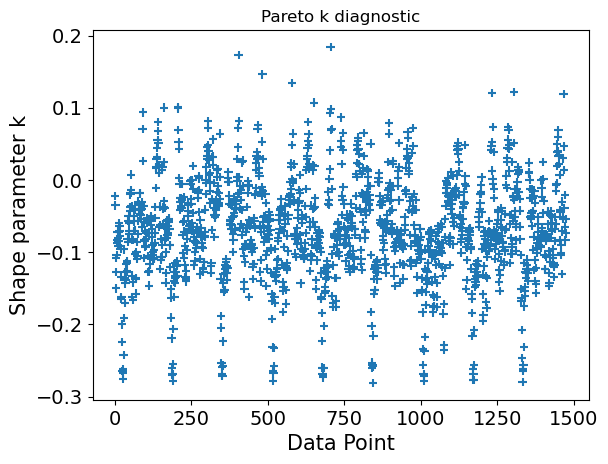

In [2]:
with pm.Model() as LH:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Pd + np.log(1-Ag_comp)
    rate = observables(log_rate) 

trace_LH, loo_LH = fit_and_evaluate(LH)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0   0.012  0.006   0.001    0.023      0.000    0.000     953.0    1030.0    1.0
deltaG4_0   0.019  0.003   0.013    0.024      0.000    0.000    1718.0    2370.0    1.0
Gact2_0     0.564  0.004   0.556    0.571      0.000    0.000    1048.0    1051.0    1.0
sigma_rel   1.786  0.075   1.641    1.926      0.002    0.001    1877.0    2349.0    1.0
sigma_base  0.003  0.002   0.000    0.007      0.000    0.000    2446.0    1667.0    1.0
exponent    0.683  0.016   0.655    0.713      0.000    0.000    2297.0    2416.0    1.0


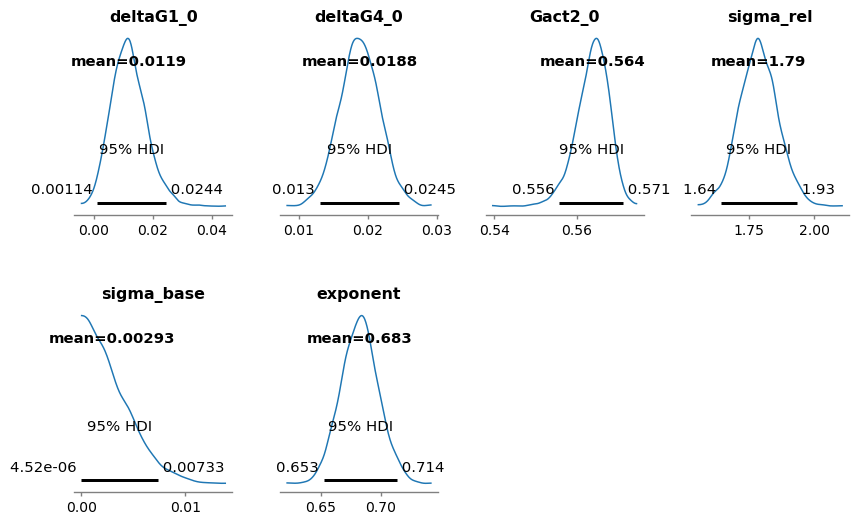

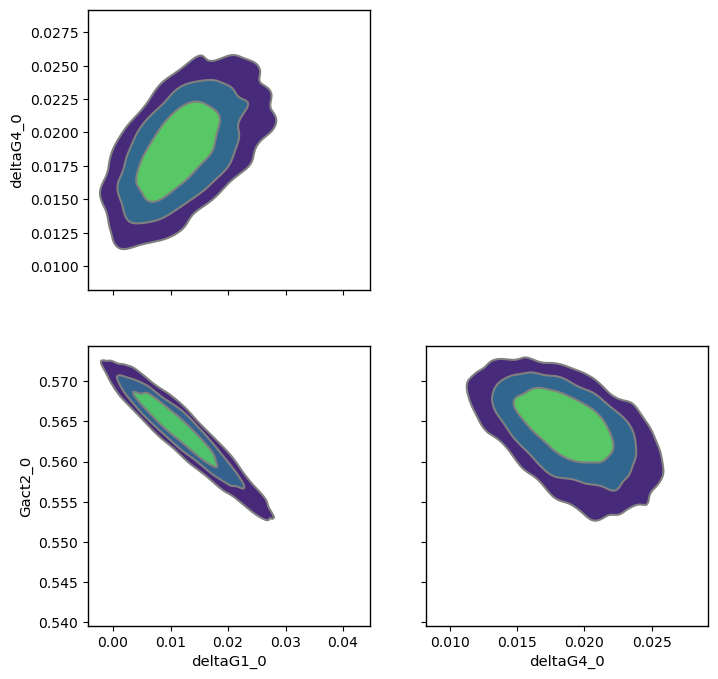

Sampling: [rate]


rate: 0.597


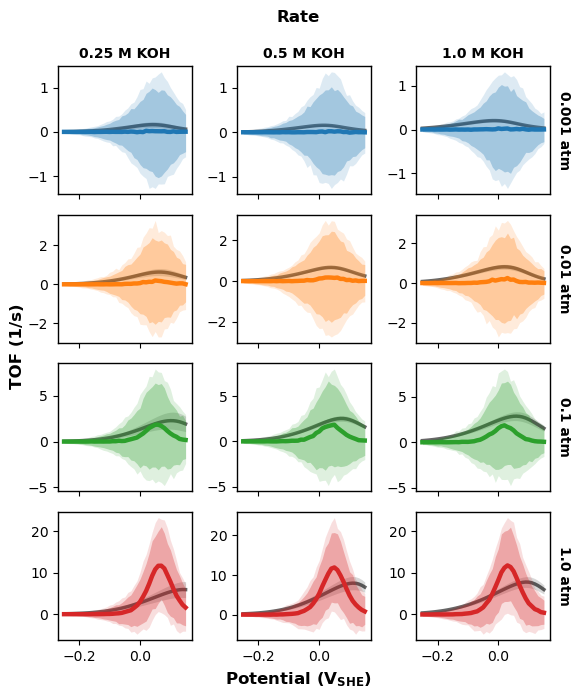

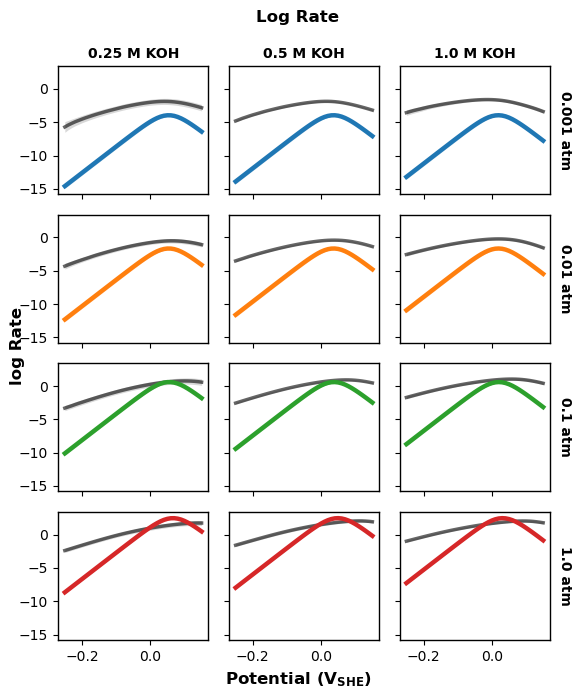

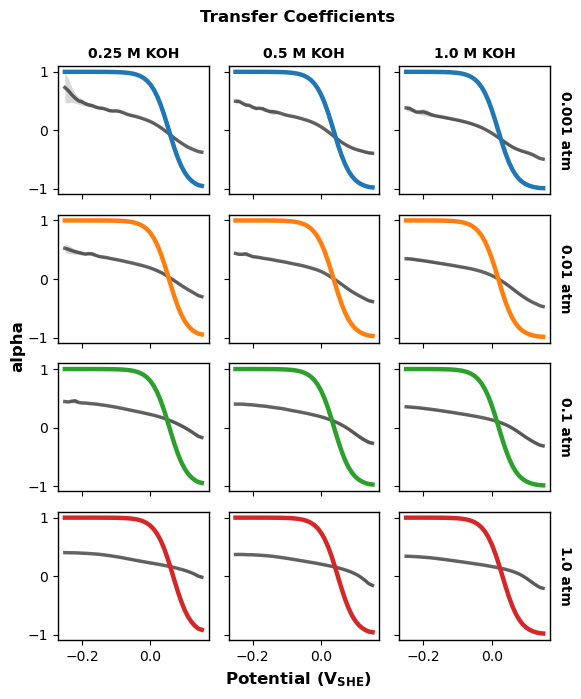

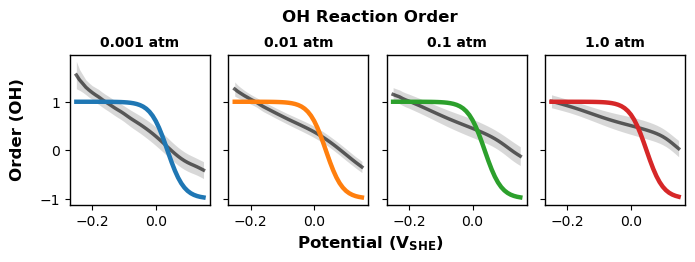

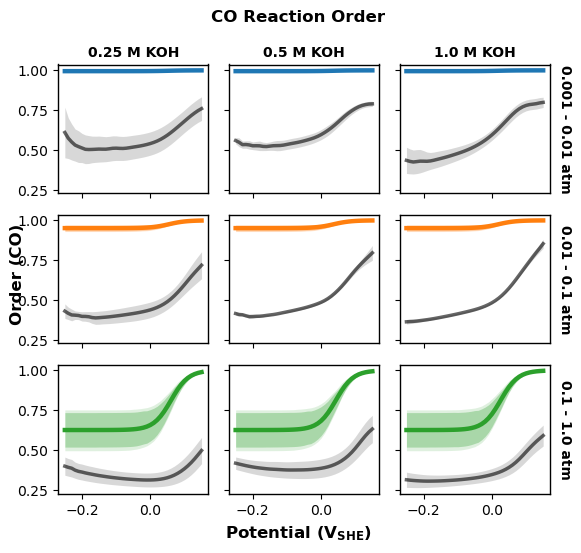

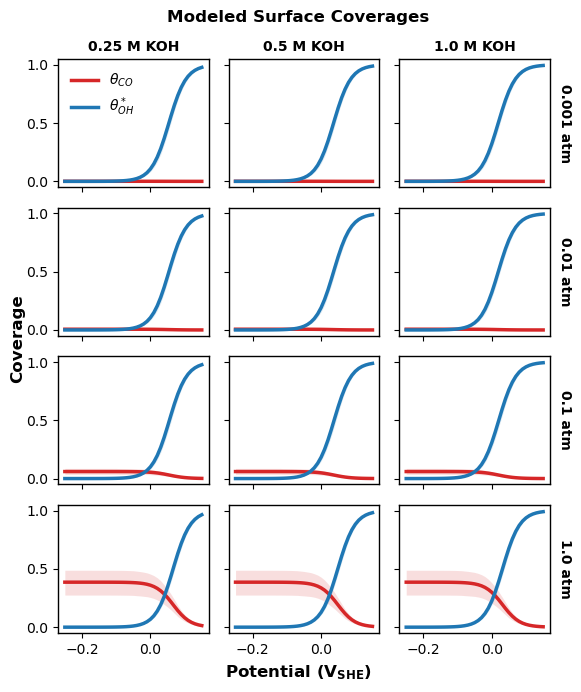

In [3]:
ppc_LH = plot_posteriors(trace_LH, LH)
plot_model_fits(trace_LH, ppc_LH); plot_coverages(trace_LH)

# BF

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.43,7
,3000,0,0.49,7
,3000,0,0.45,15
,3000,0,0.50,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -231.81    60.43
p_loo       13.48        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



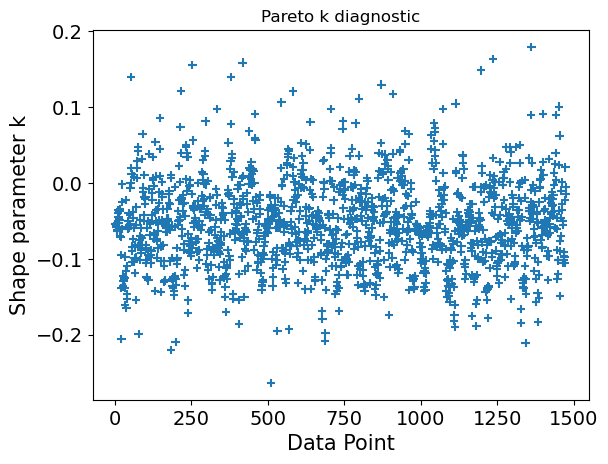

In [4]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.071  0.001  -0.073   -0.068      0.000    0.000    1234.0    2153.0    1.0
deltaG4_0   0.130  0.003   0.125    0.137      0.000    0.000    3151.0    2804.0    1.0
deltaG5_0  -0.143  0.002  -0.148   -0.139      0.000    0.000    2561.0    2660.0    1.0
Gact2_0     0.706  0.001   0.704    0.708      0.000    0.000    1237.0    1962.0    1.0
sigma_rel   0.325  0.016   0.296    0.353      0.000    0.000    2811.0    2879.0    1.0
sigma_base  0.060  0.003   0.055    0.066      0.000    0.000    3157.0    2872.0    1.0
exponent    2.589  0.108   2.379    2.783      0.002    0.002    2163.0    2651.0    1.0


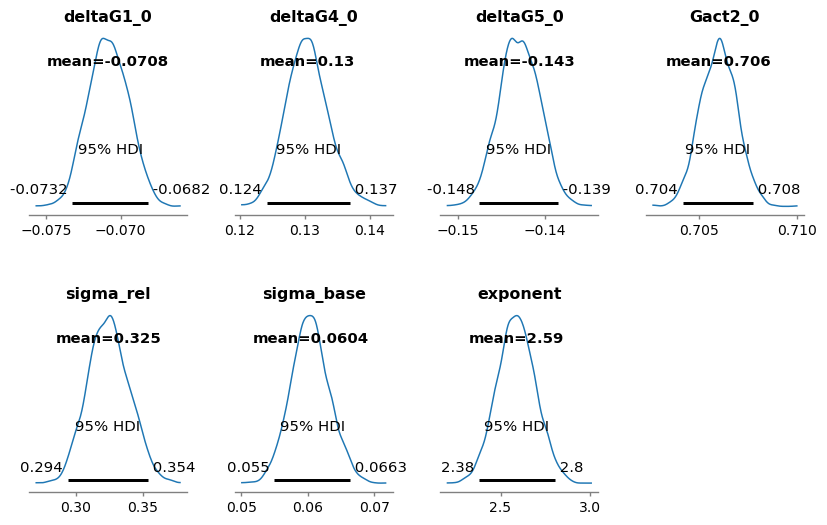

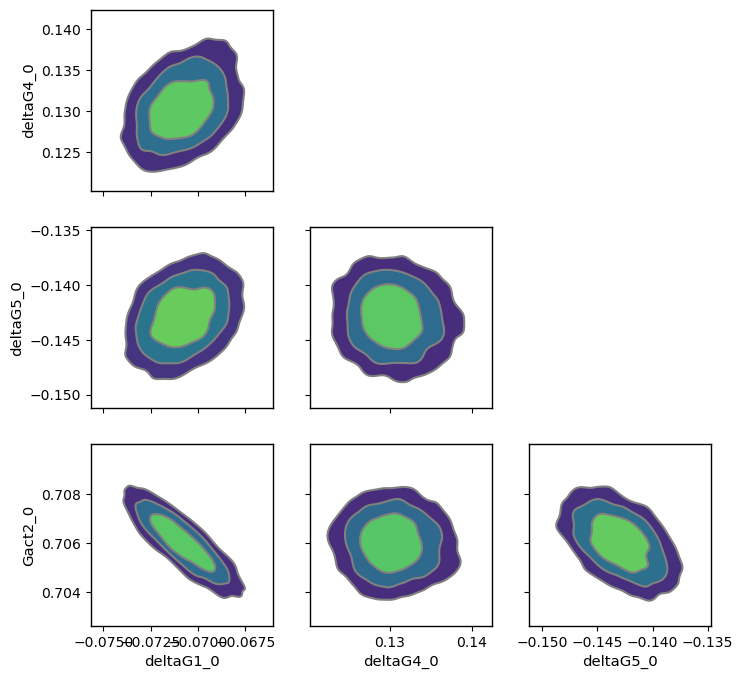

Sampling: [rate]


rate: 0.565


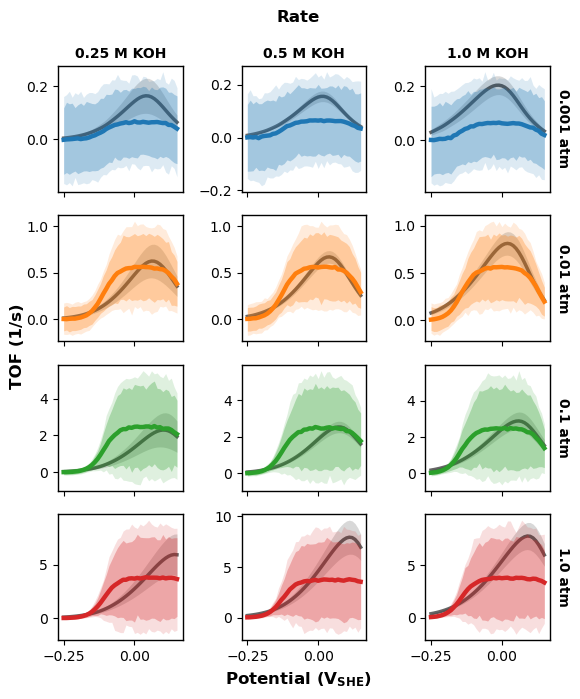

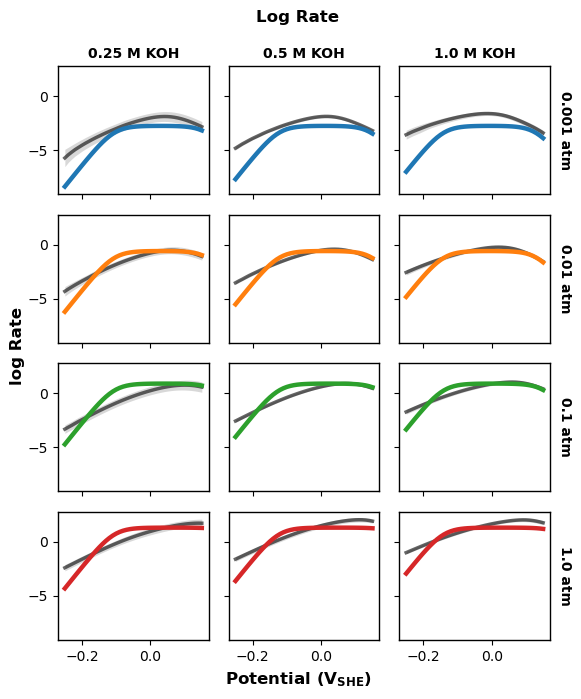

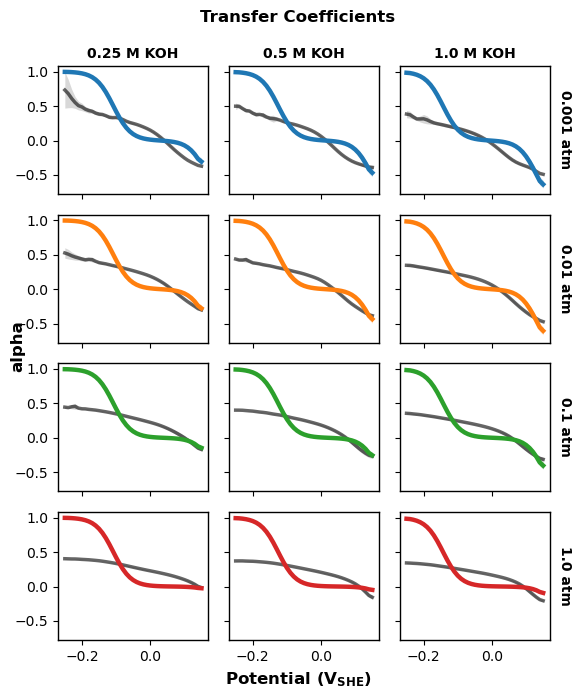

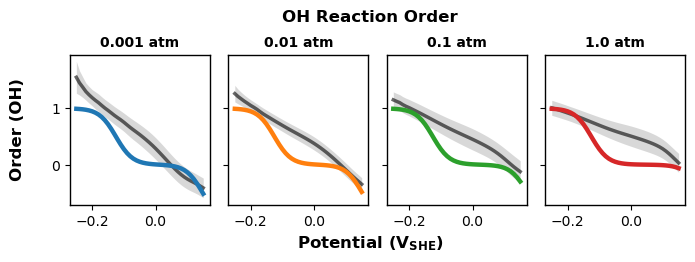

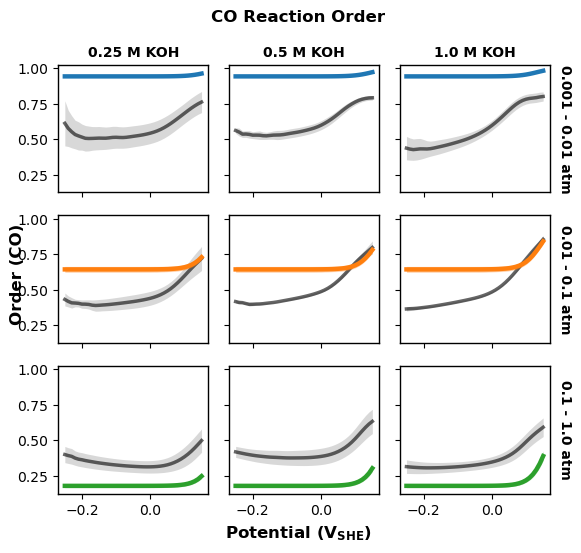

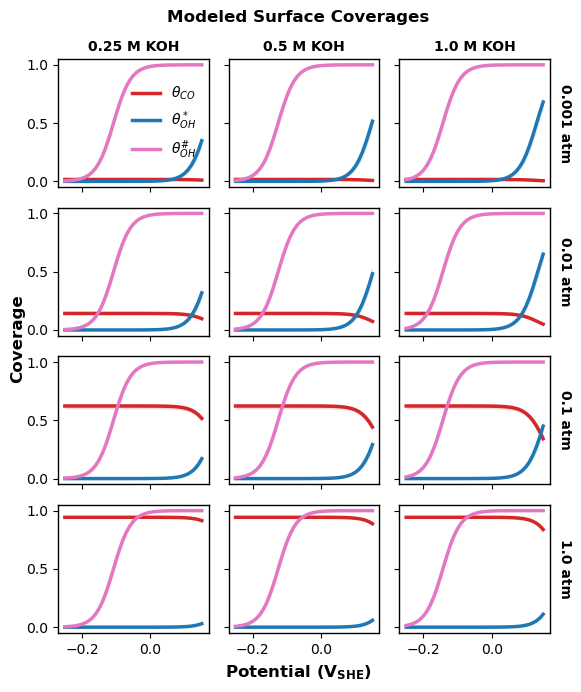

In [5]:
ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF); plot_coverages(trace_BF)

# ER

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.47,15
,3000,0,0.51,7
,3000,0,0.41,7
,3000,0,0.44,11


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   178.62    64.44
p_loo        9.46        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



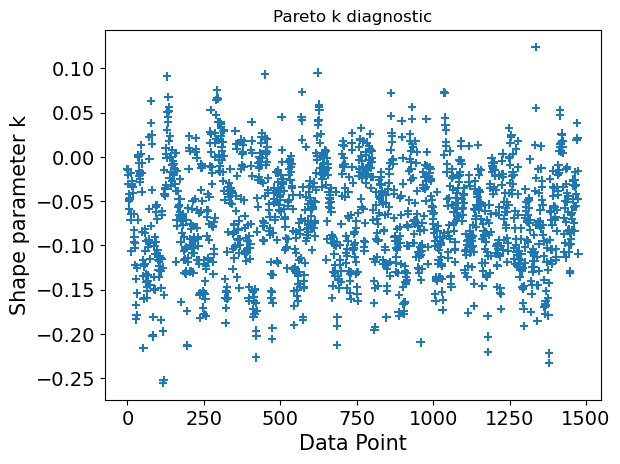

In [6]:
with pm.Model() as ER:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER, loo_ER = fit_and_evaluate(ER)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.088  0.001  -0.091   -0.085      0.000    0.000    1546.0    1874.0    1.0
deltaG4_0   0.038  0.002   0.035    0.042      0.000    0.000    1885.0    2431.0    1.0
Gact2_0     0.695  0.001   0.694    0.696      0.000    0.000    1470.0    1895.0    1.0
beta_2      0.296  0.004   0.289    0.304      0.000    0.000    1772.0    2468.0    1.0
sigma_rel   0.316  0.011   0.296    0.338      0.000    0.000    2671.0    2831.0    1.0
sigma_base  0.033  0.002   0.028    0.037      0.000    0.000    2401.0    2659.0    1.0
exponent    2.158  0.058   2.041    2.261      0.001    0.001    2933.0    2711.0    1.0


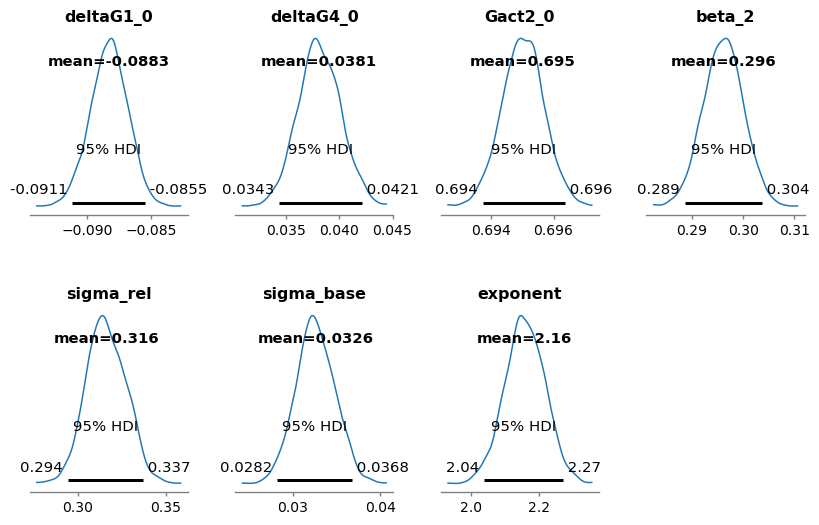

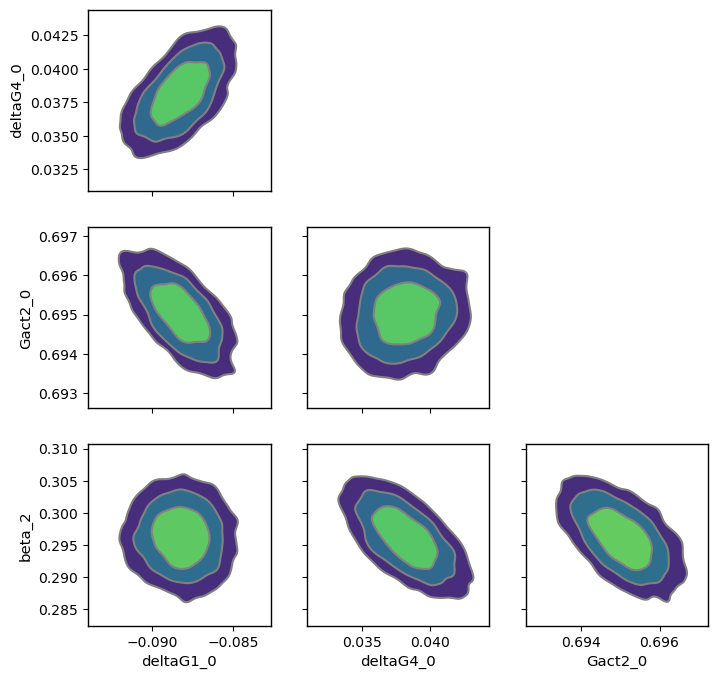

Sampling: [rate]


rate: 0.699


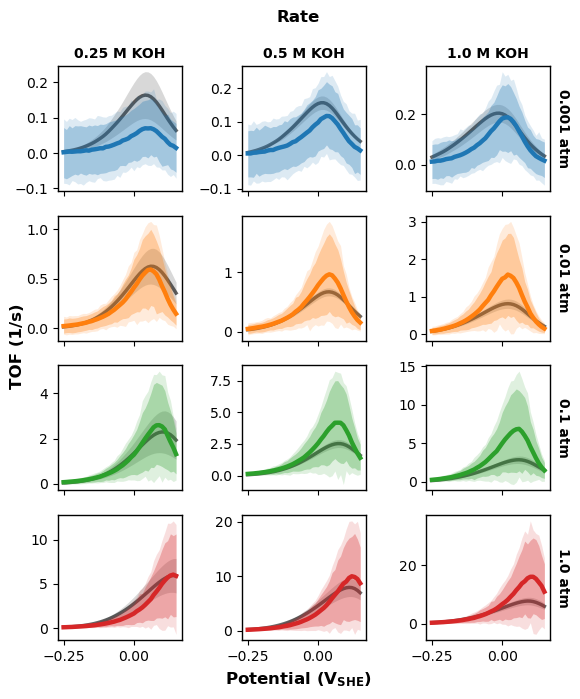

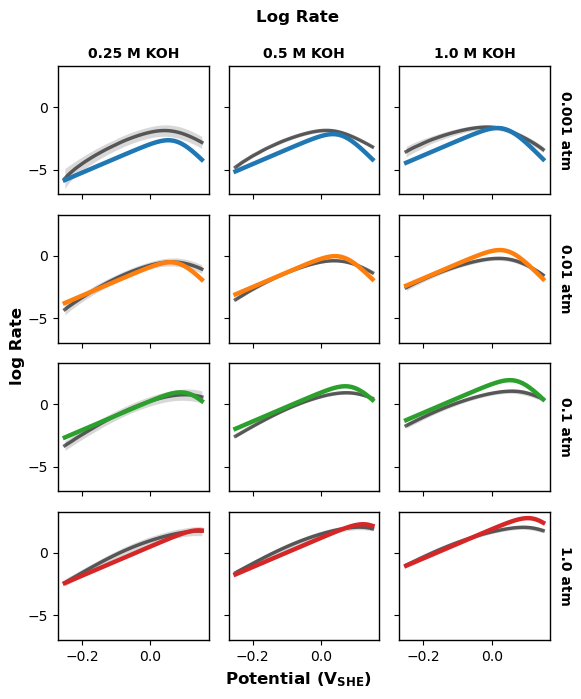

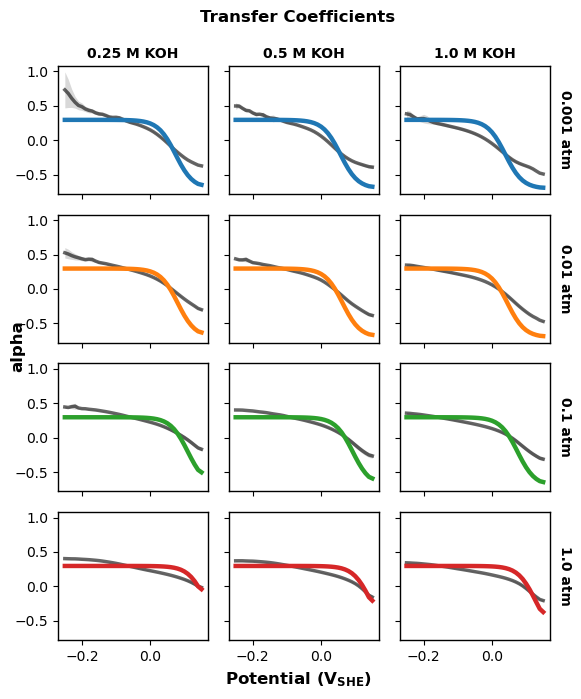

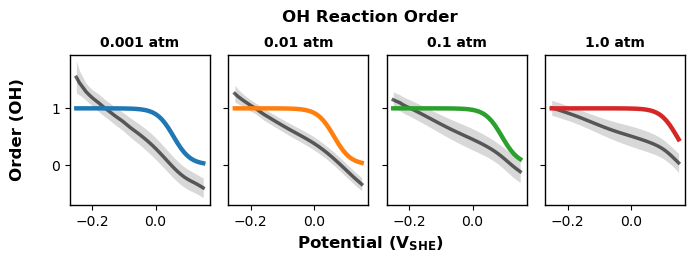

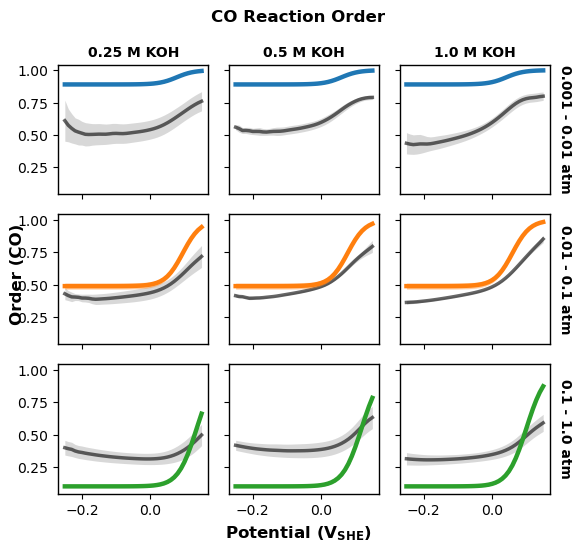

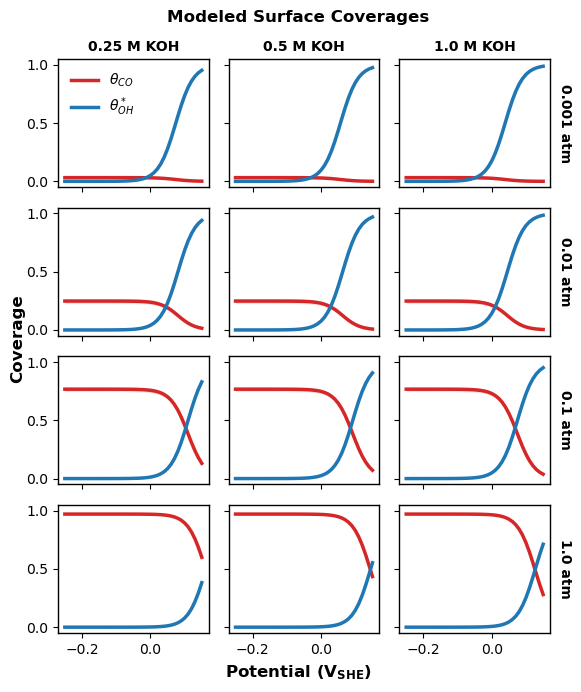

In [7]:
ppc_ER = plot_posteriors(trace_ER, ER)
plot_model_fits(trace_ER, ppc_ER); plot_coverages(trace_ER)

# BF ER

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.32,15
,3000,0,0.35,15
,3000,0,0.38,15
,3000,0,0.35,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   389.70    57.65
p_loo       14.04        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



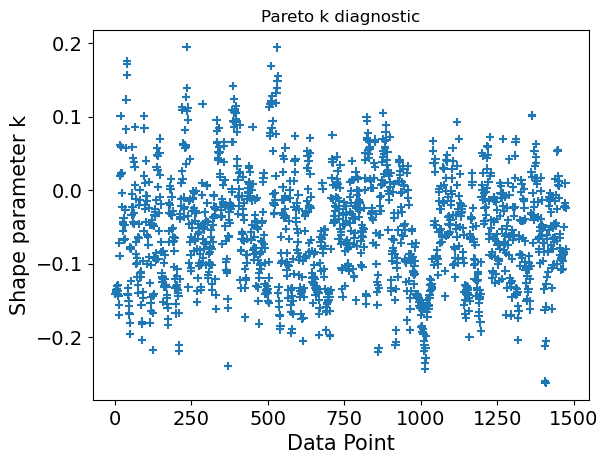

In [8]:
with pm.Model() as BF_ER:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER, loo_BF_ER = fit_and_evaluate(BF_ER)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.077  0.001  -0.079   -0.075      0.000    0.000    1806.0    2110.0    1.0
deltaG4_0   0.083  0.003   0.078    0.089      0.000    0.000    1228.0    2169.0    1.0
deltaG5_0  -0.103  0.003  -0.109   -0.097      0.000    0.000    2004.0    2629.0    1.0
Gact2_BF_0  0.722  0.002   0.718    0.725      0.000    0.000    1268.0    1823.0    1.0
Gact2_ER_0  0.715  0.001   0.713    0.718      0.000    0.000    1205.0    1779.0    1.0
beta_2      0.205  0.008   0.190    0.220      0.000    0.000    1141.0    1835.0    1.0
sigma_rel   0.237  0.011   0.218    0.258      0.000    0.000    2488.0    2657.0    1.0
sigma_base  0.041  0.002   0.036    0.045      0.000    0.000    2303.0    1981.0    1.0
exponent    2.273  0.094   2.094    2.439      0.002    0.001    2882.0    3003.0    1.0


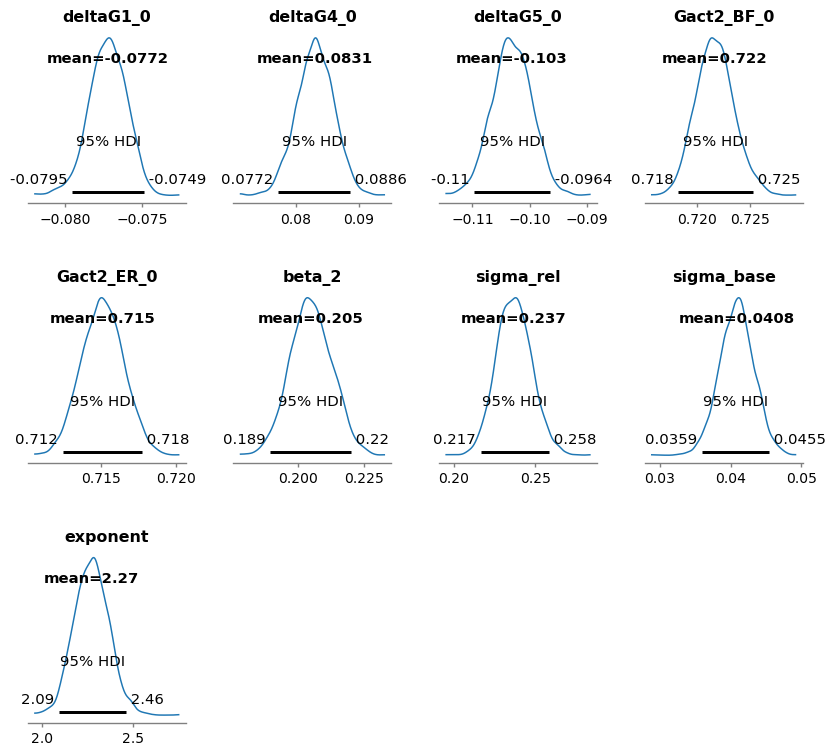

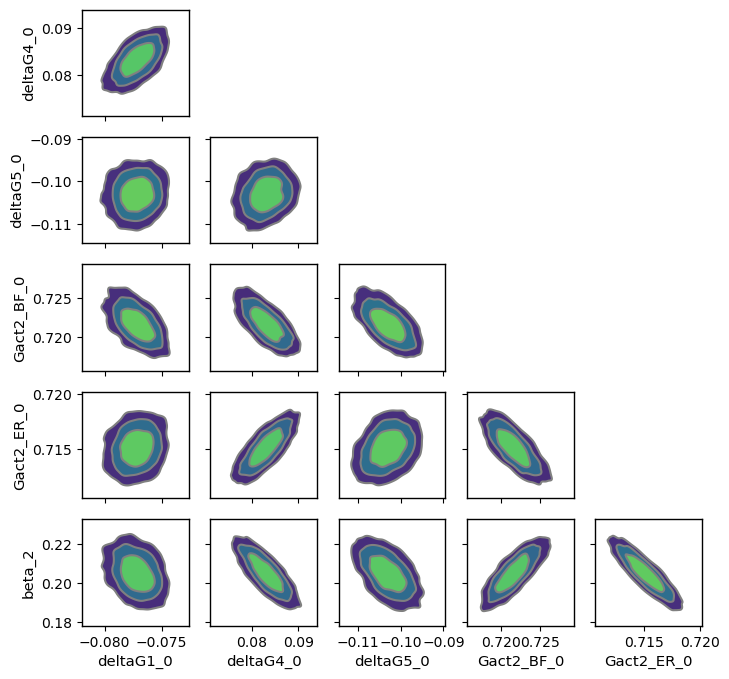

Sampling: [rate]


rate: 0.747


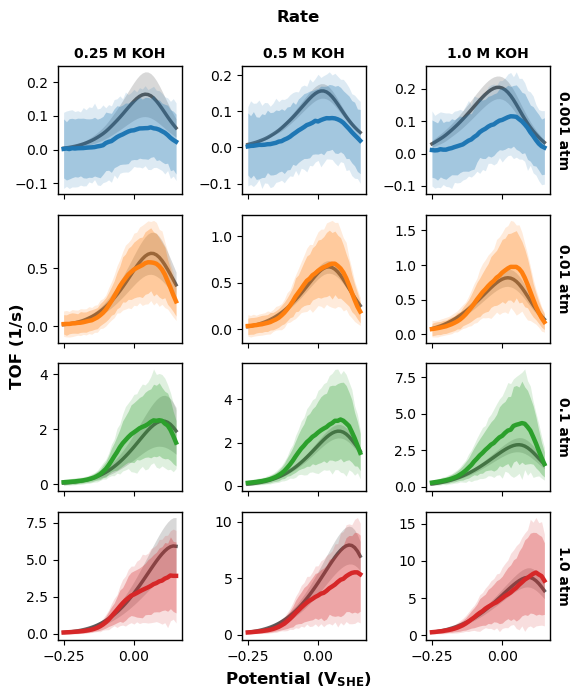

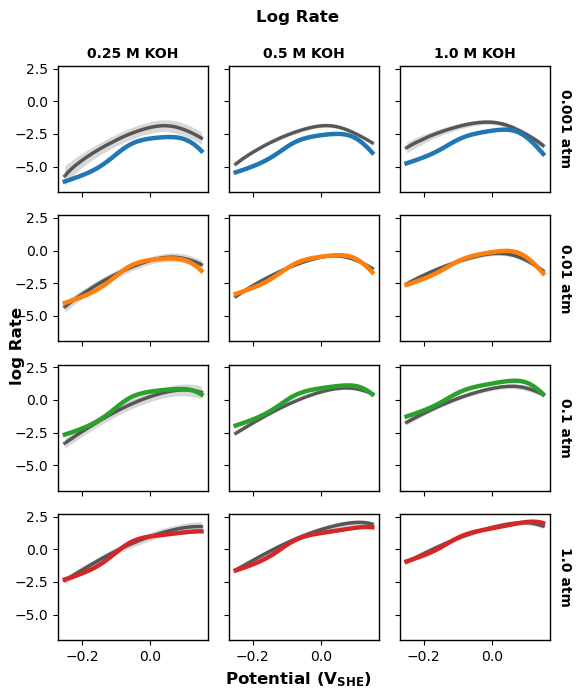

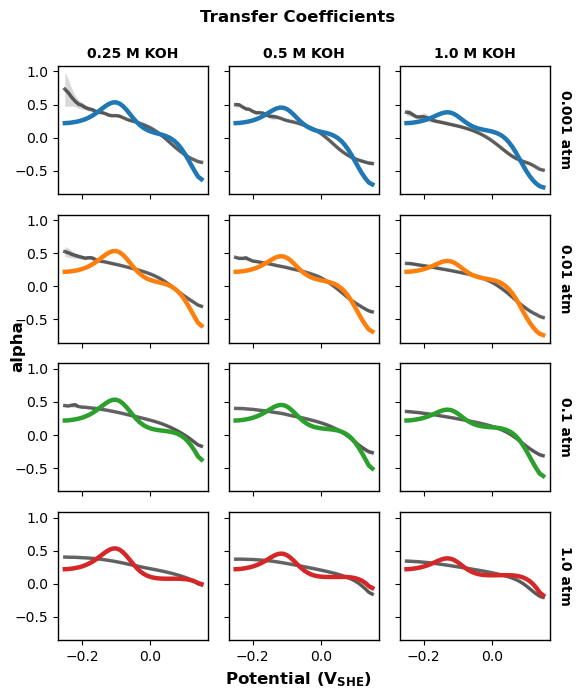

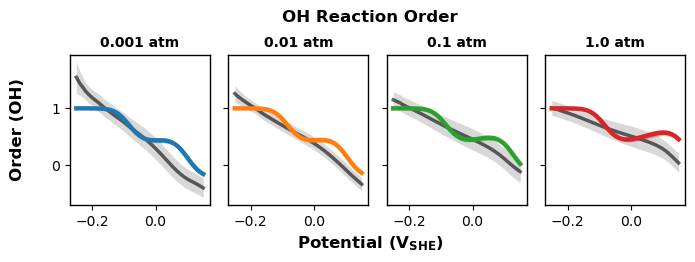

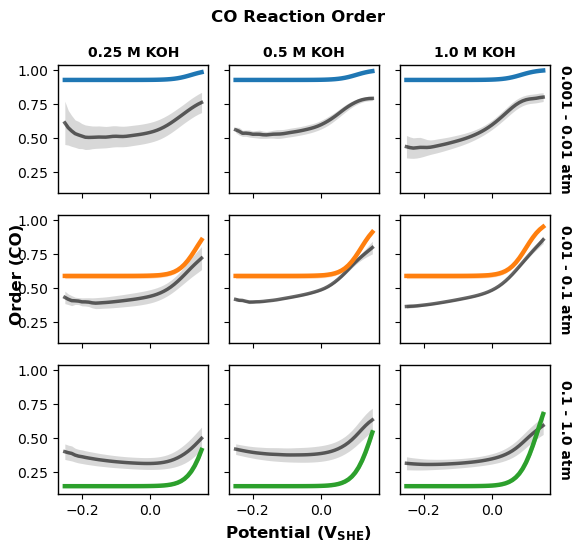

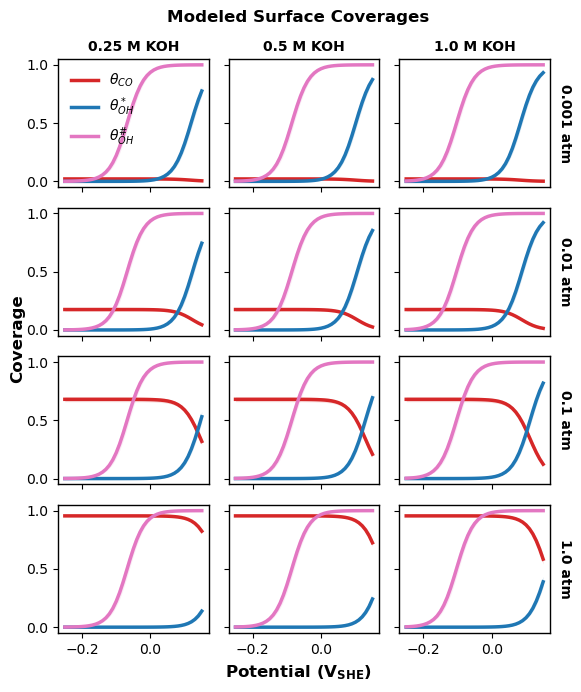

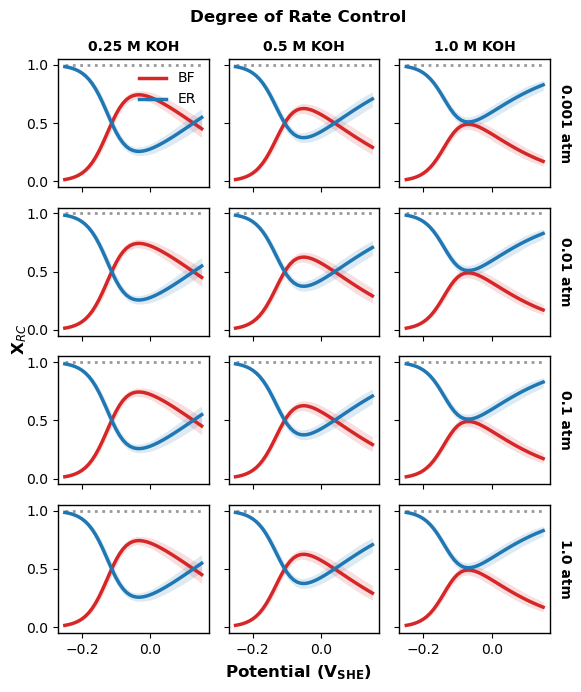

In [9]:
ppc_BF_ER = plot_posteriors(trace_BF_ER, BF_ER)
plot_model_fits(trace_BF_ER, ppc_BF_ER); plot_coverages(trace_BF_ER)
plot_drc(BF_ER, trace_BF_ER, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF ER LH

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.37,31
,3000,0,0.35,15
,3000,0,0.31,15
,3000,0,0.31,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   409.61    57.35
p_loo       14.50        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



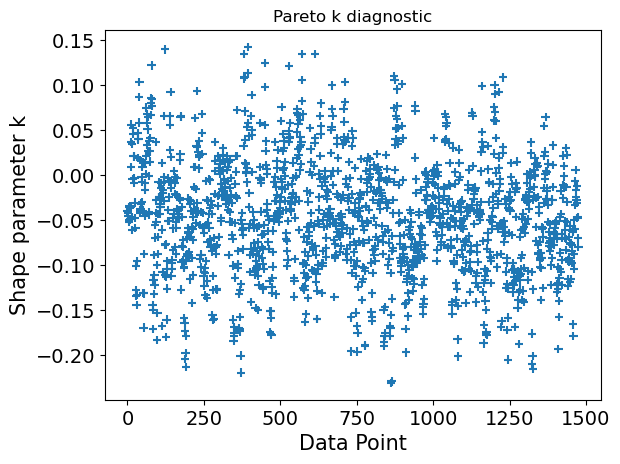

In [10]:
with pm.Model() as BF_ER_LH:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    2c. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_ER, log_rate_LH]), axis=0)
    rate = observables(log_rate) 

trace_BF_ER_LH, loo_BF_ER_LH = fit_and_evaluate(BF_ER_LH)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.077  0.001  -0.079   -0.074      0.000    0.000    2271.0    2523.0    1.0
deltaG4_0   0.067  0.003   0.062    0.072      0.000    0.000    1419.0    1755.0    1.0
deltaG5_0  -0.112  0.004  -0.119   -0.105      0.000    0.000    1671.0    2567.0    1.0
Gact2_BF_0  0.726  0.002   0.722    0.729      0.000    0.000    1112.0    1707.0    1.0
Gact2_ER_0  0.714  0.001   0.711    0.716      0.000    0.000    1371.0    2152.0    1.0
Gact2_LH_0  0.644  0.004   0.637    0.652      0.000    0.000    2375.0    2447.0    1.0
beta_2      0.214  0.007   0.201    0.227      0.000    0.000    1273.0    1967.0    1.0
sigma_rel   0.230  0.010   0.212    0.248      0.000    0.000    3374.0    3111.0    1.0
sigma_base  0.041  0.002   0.037    0.045      0.000    0.000    3241.0    3092.0    1.0
exponent    2.322  0.089   2.148    2.481      0.001    0.001    3940.0    2822.0    1.0


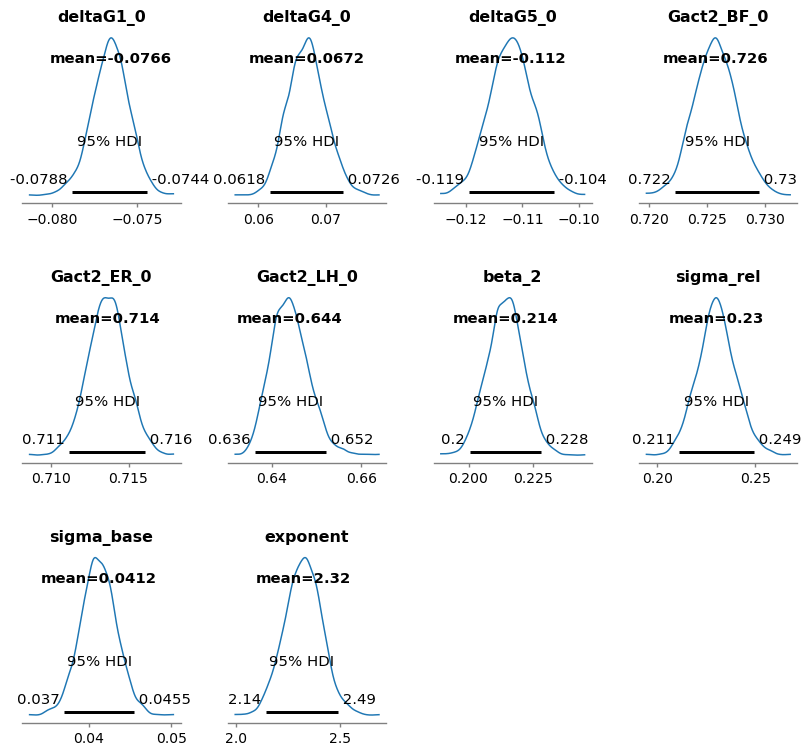

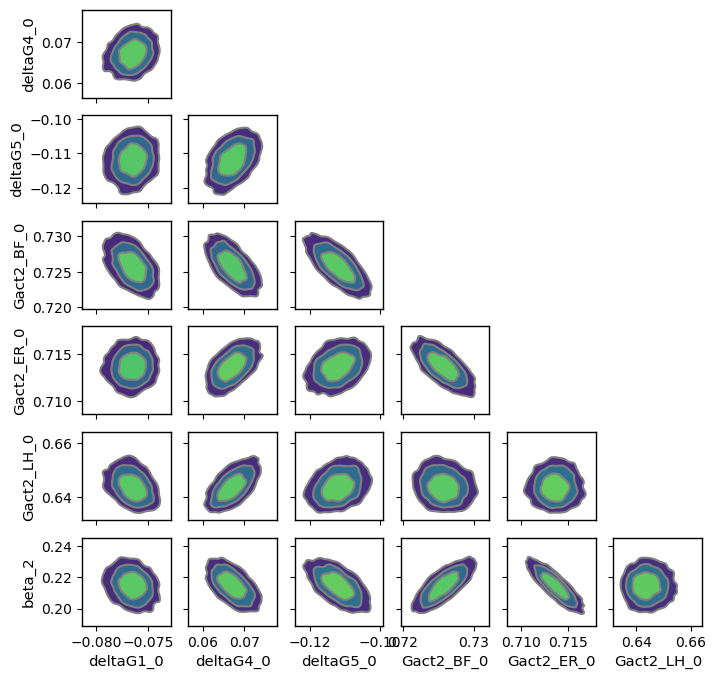

Sampling: [rate]


rate: 0.748


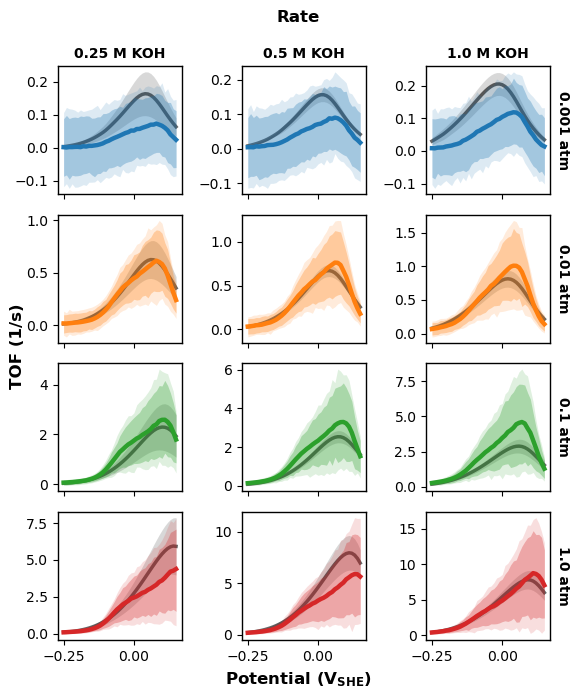

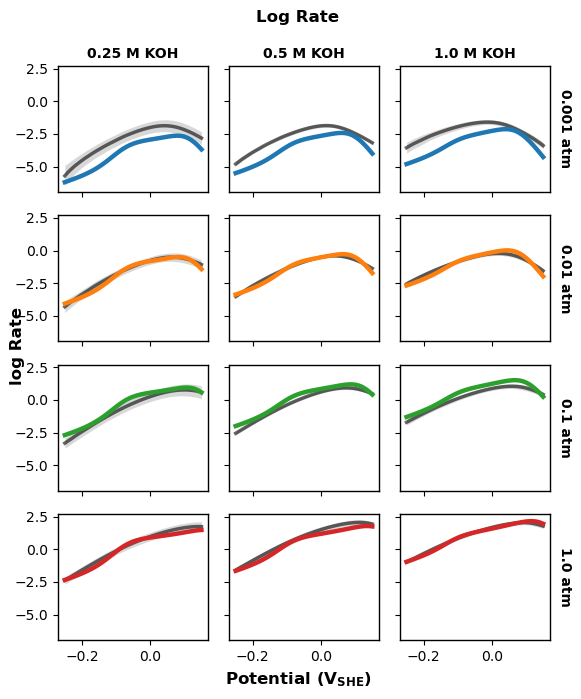

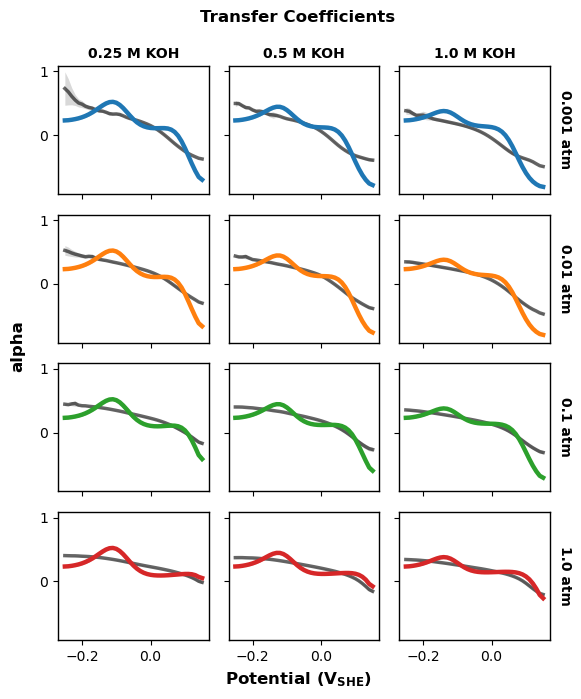

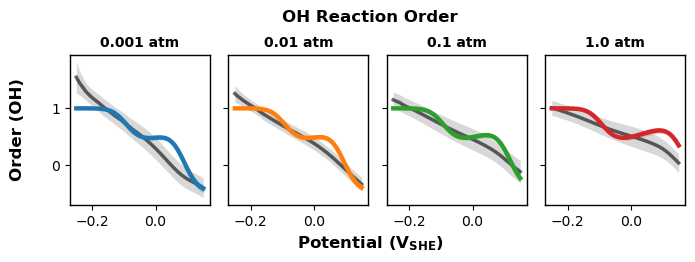

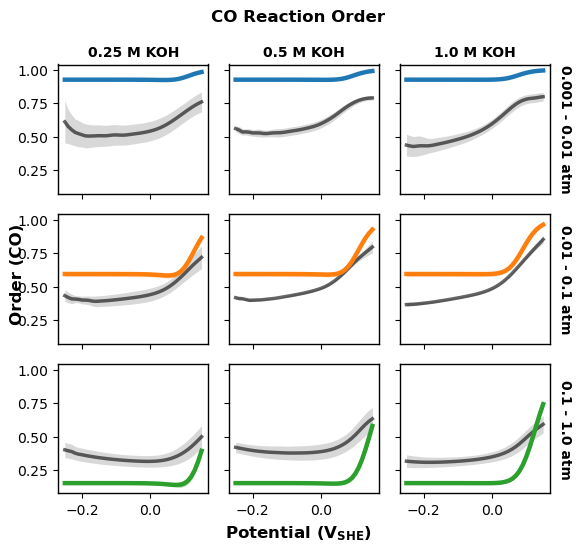

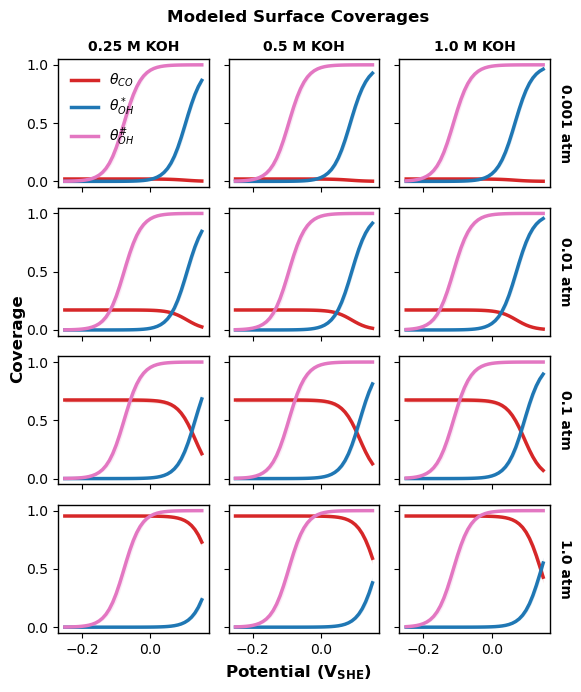

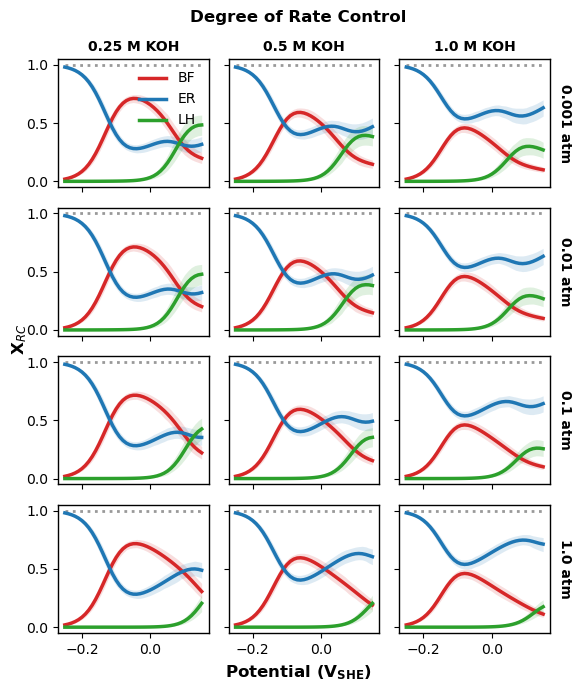

In [11]:
ppc_BF_ER_LH = plot_posteriors(trace_BF_ER_LH, BF_ER_LH)
plot_model_fits(trace_BF_ER_LH, ppc_BF_ER_LH); plot_coverages(trace_BF_ER_LH)
plot_drc(BF_ER_LH, trace_BF_ER_LH, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['BF', 'ER', 'LH'])

# BF PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.26,7
,3000,0,0.26,15
,3000,0,0.31,31
,3000,0,0.26,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   492.54    54.74
p_loo       10.72        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



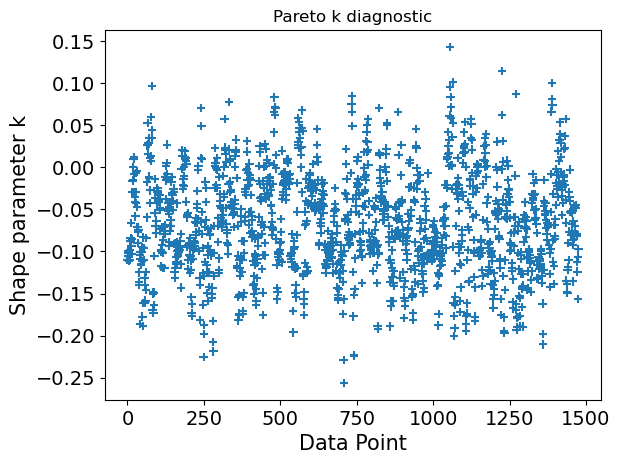

In [12]:
with pm.Model() as BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate = log_rate_BF
    rate = observables(log_rate) 

trace_BF_PCT_Ag, loo_BF_PCT_Ag = fit_and_evaluate(BF_PCT_Ag)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.077  0.001  -0.079   -0.075      0.000    0.000    2207.0    2484.0    1.0
deltaG4_0   0.086  0.003   0.081    0.091      0.000    0.000    1449.0    2056.0    1.0
deltaG5_0  -0.028  0.002  -0.033   -0.024      0.000    0.000    1268.0    1437.0    1.0
Gact2_0     0.695  0.001   0.693    0.697      0.000    0.000    1387.0    1602.0    1.0
beta_2      0.079  0.013   0.055    0.104      0.000    0.000    1588.0    1754.0    1.0
q           0.344  0.013   0.320    0.368      0.000    0.000    1389.0    1906.0    1.0
sigma_rel   0.212  0.008   0.196    0.229      0.000    0.000    3664.0    3272.0    1.0
sigma_base  0.041  0.002   0.038    0.045      0.000    0.000    3562.0    2909.0    1.0
exponent    2.301  0.093   2.139    2.483      0.002    0.001    2715.0    2541.0    1.0


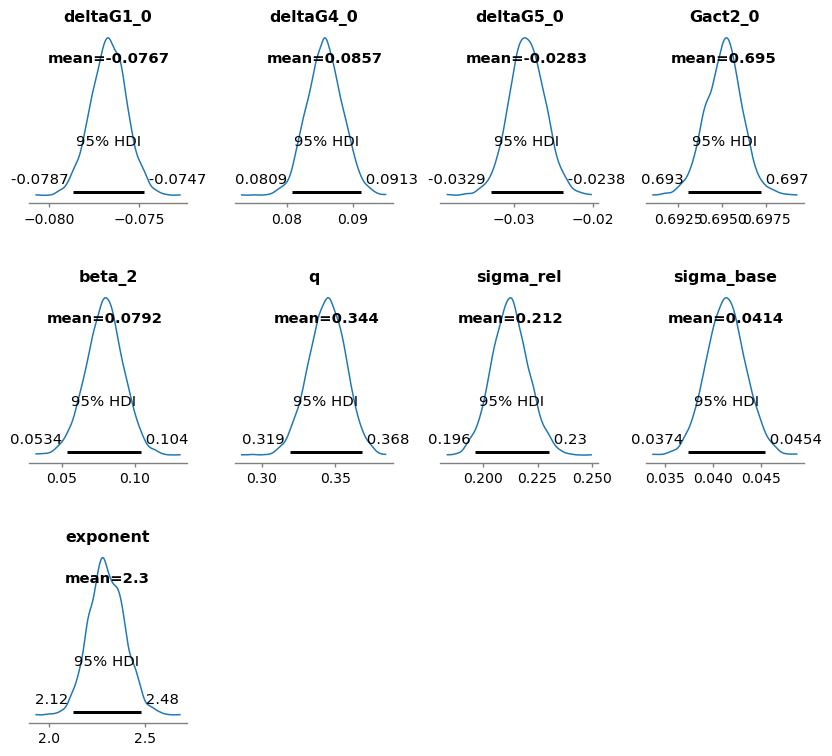

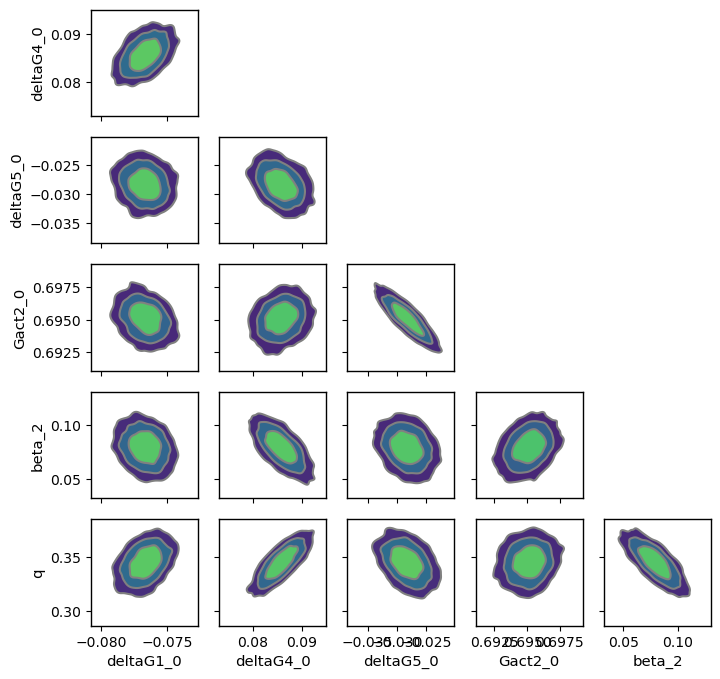

Sampling: [rate]


rate: 0.771


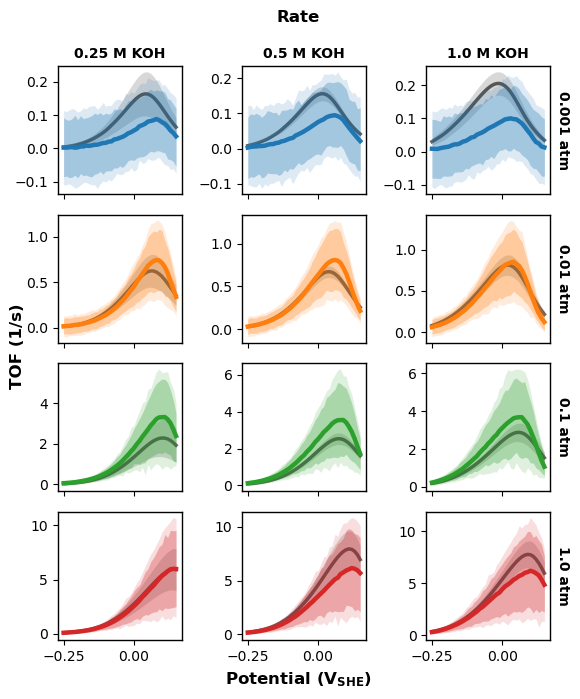

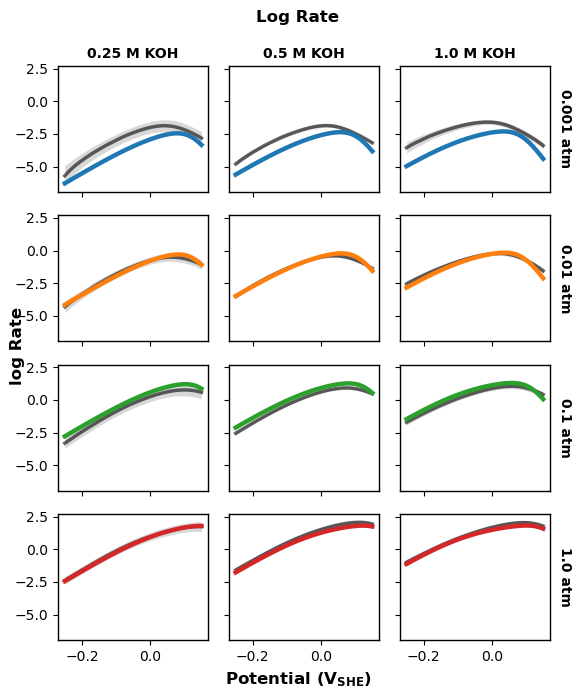

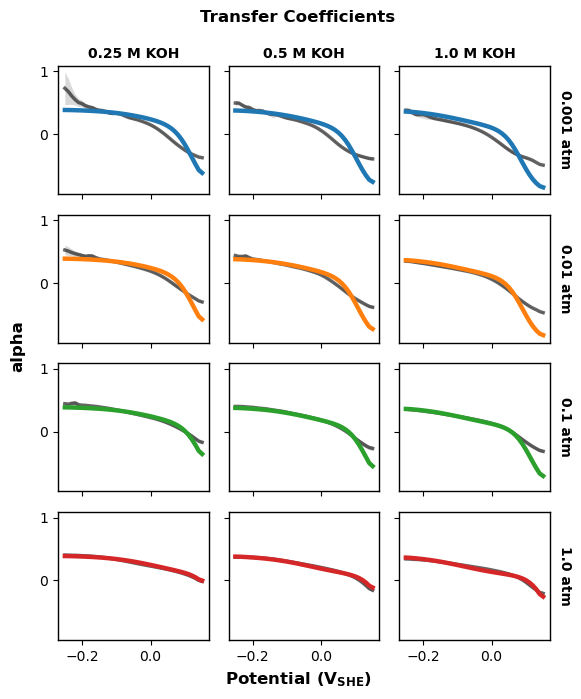

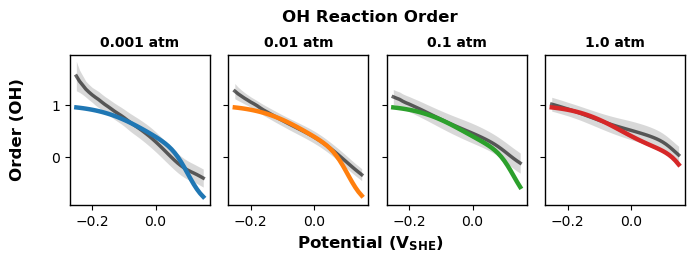

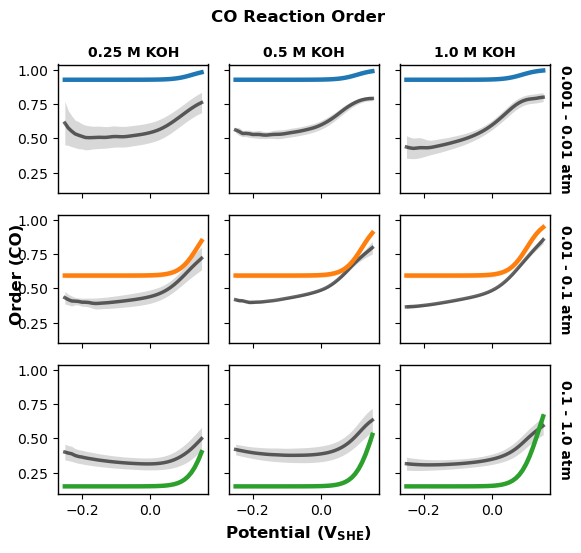

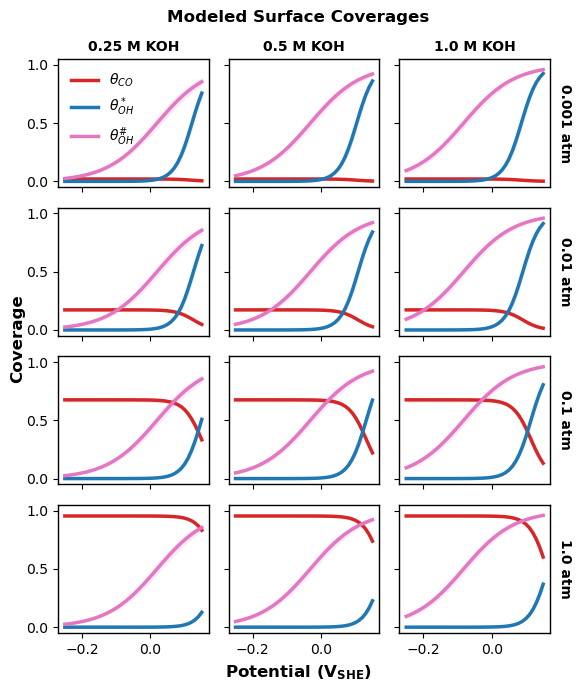

In [13]:
ppc_BF_PCT_Ag = plot_posteriors(trace_BF_PCT_Ag, BF_PCT_Ag)
plot_model_fits(trace_BF_PCT_Ag, ppc_BF_PCT_Ag); plot_coverages(trace_BF_PCT_Ag)

# BF LH PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.13,31
,3000,0,0.17,31
,3000,0,0.15,31
,3000,0,0.13,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   492.42    54.73
p_loo       10.83        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



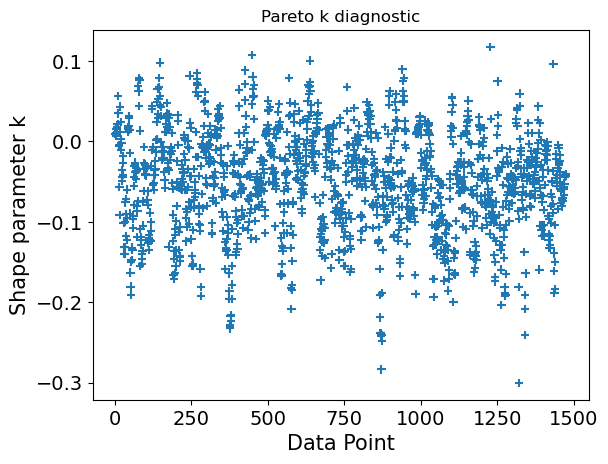

In [14]:
with pm.Model() as BF_LH_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2 * (1.0 - q) * E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_LH)
    rate = observables(log_rate) 

trace_BF_LH_PCT_Ag, loo_BF_LH_PCT_Ag = fit_and_evaluate(BF_LH_PCT_Ag, target_accept=0.95)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.077  0.001  -0.078   -0.075      0.000    0.000    2192.0    2472.0   1.00
deltaG4_0   0.086  0.003   0.081    0.091      0.000    0.000    1423.0    2106.0   1.00
deltaG5_0  -0.028  0.002  -0.033   -0.024      0.000    0.000    1105.0    1313.0   1.01
Gact2_BF_0  0.695  0.001   0.693    0.697      0.000    0.000    1142.0    1263.0   1.00
Gact2_LH_0  0.873  0.119   0.692    1.086      0.003    0.003    2251.0    1816.0   1.00
beta_2      0.078  0.013   0.055    0.103      0.000    0.000    1137.0    1408.0   1.00
q           0.345  0.012   0.323    0.368      0.000    0.000    1185.0    1626.0   1.00
sigma_rel   0.212  0.008   0.197    0.229      0.000    0.000    3452.0    2626.0   1.00
sigma_base  0.041  0.002   0.038    0.045      0.000    0.000    4093.0    2964.0   1.00
exponent    2.302  0.094   2.121    2.471      0.002    0.001    2641.0    2620.0   1.00


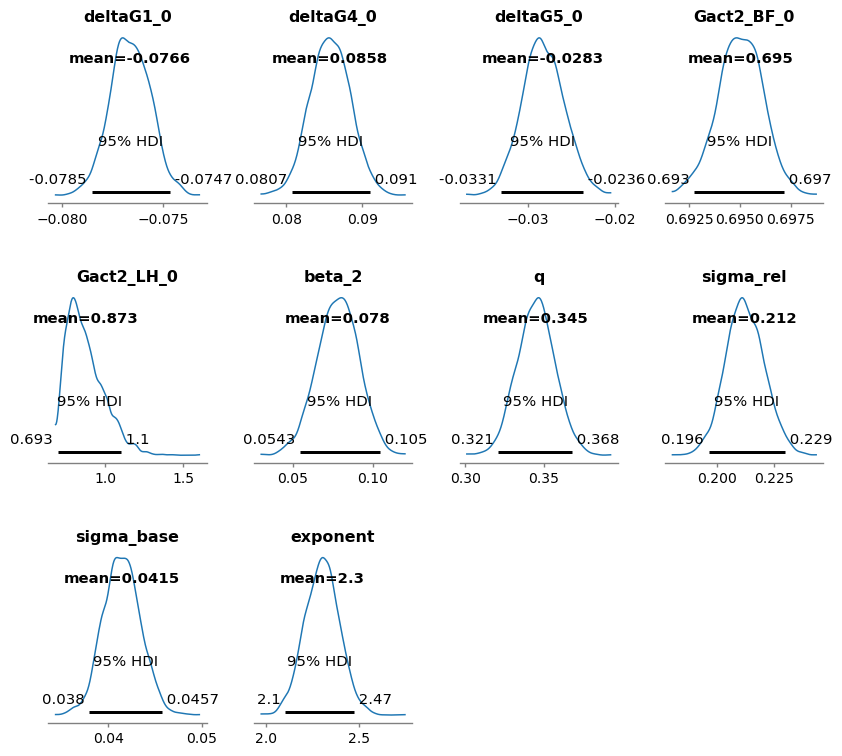

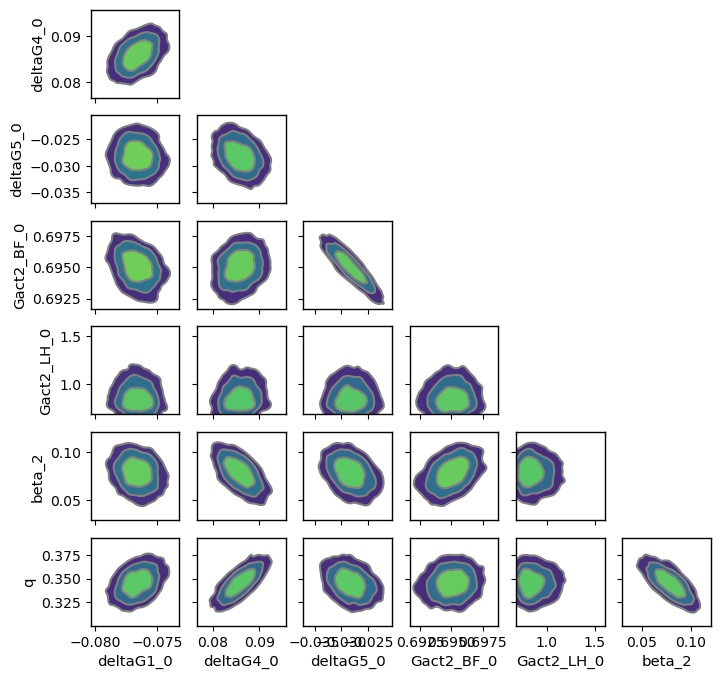

Sampling: [rate]


rate: 0.772


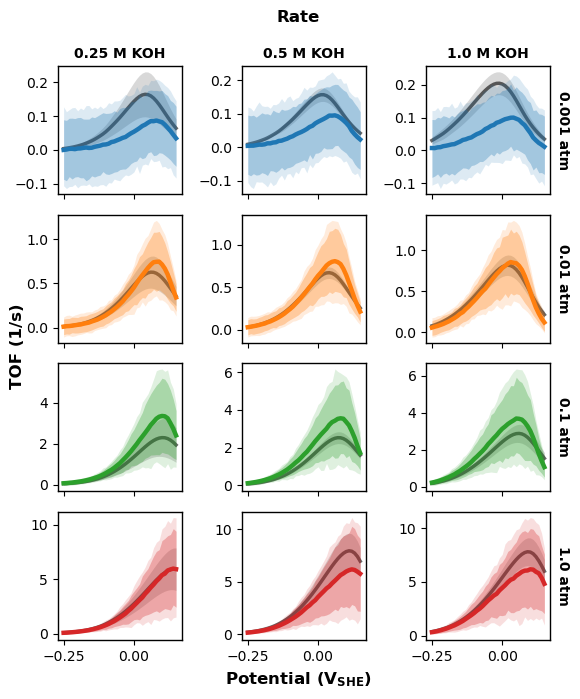

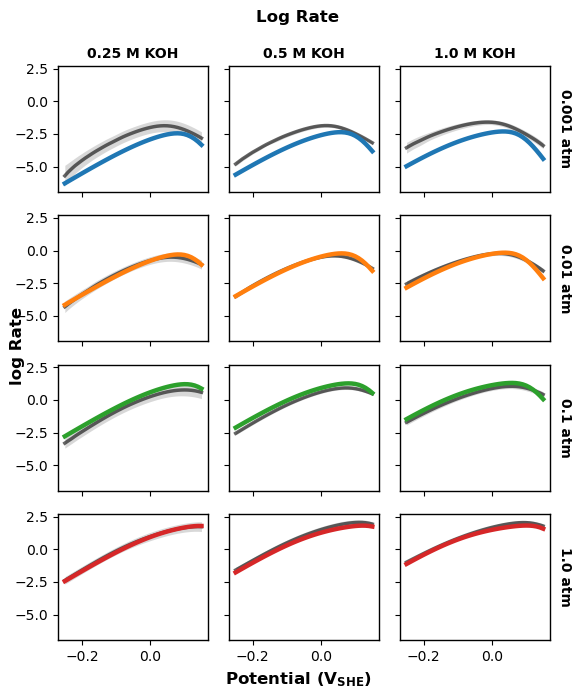

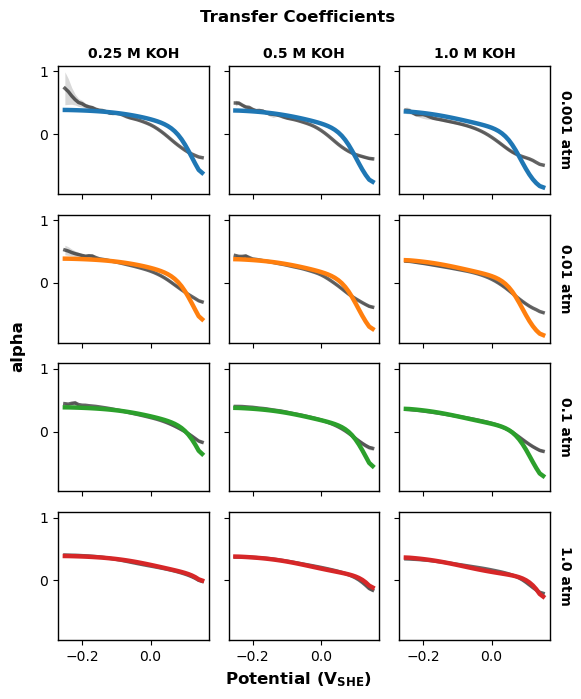

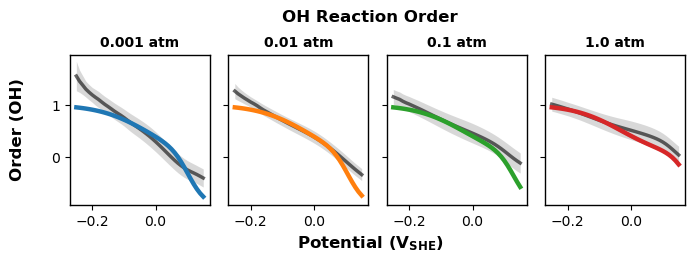

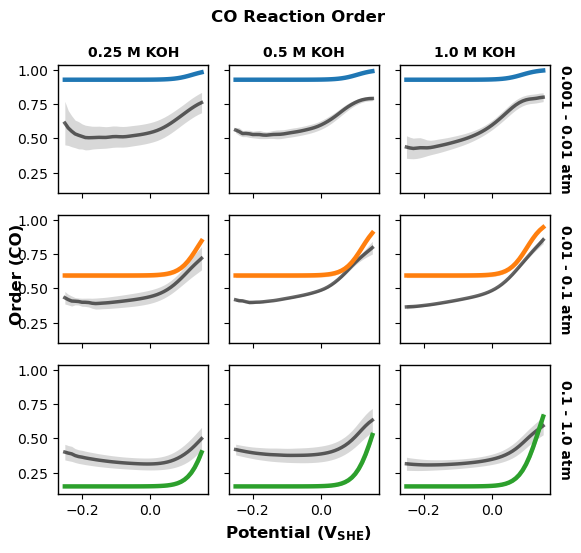

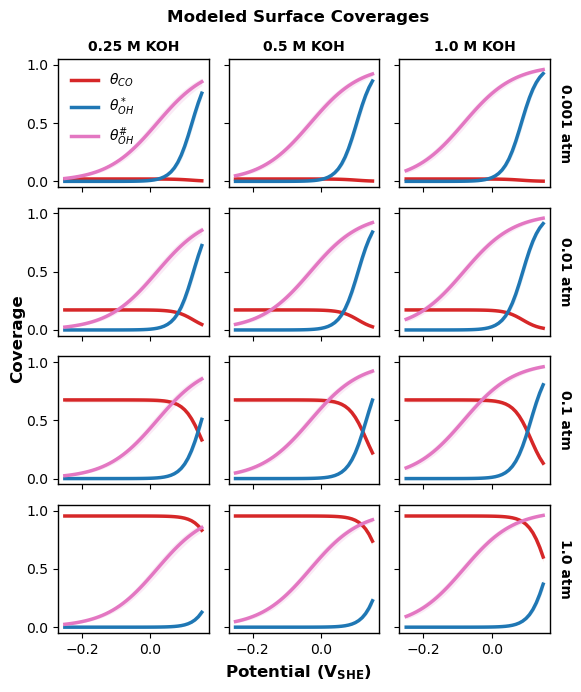

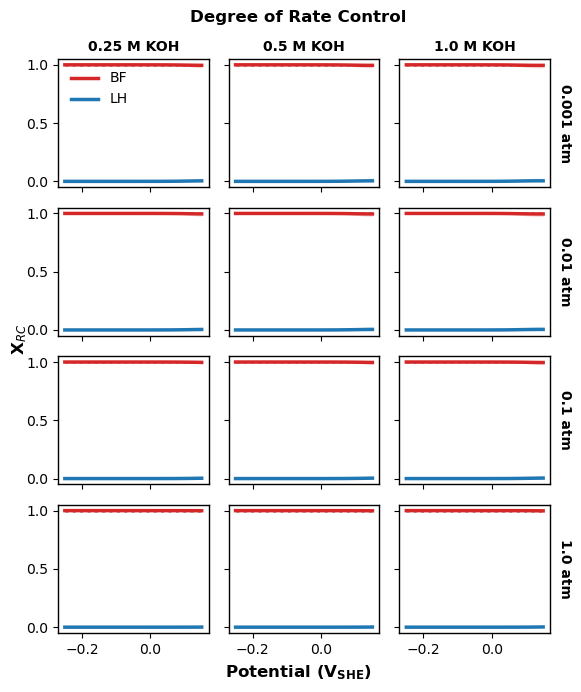

In [15]:
ppc_BF_LH_PCT_Ag = plot_posteriors(trace_BF_LH_PCT_Ag, BF_LH_PCT_Ag)
plot_model_fits(trace_BF_LH_PCT_Ag, ppc_BF_LH_PCT_Ag); plot_coverages(trace_BF_LH_PCT_Ag)
plot_drc(BF_LH_PCT_Ag, trace_BF_LH_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_LH_0'], perturb_labels=['BF', 'LH'])

# BF ER PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.14,63
,3000,0,0.18,31
,3000,0,0.18,63
,3000,0,0.17,63


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   520.69    54.49
p_loo       12.06        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



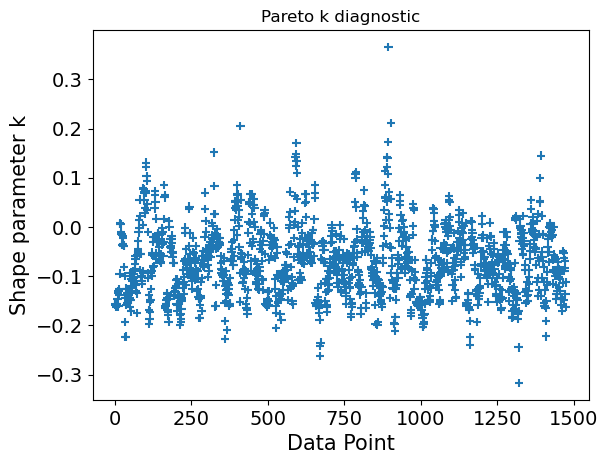

In [16]:
with pm.Model() as BF_ER_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
     # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER_PCT_Ag, loo_BF_ER_PCT_Ag = fit_and_evaluate(BF_ER_PCT_Ag, target_accept=0.95)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.078  0.001  -0.079   -0.076      0.000    0.000    3412.0    2947.0   1.00
deltaG4_0   0.076  0.003   0.071    0.081      0.000    0.000     705.0     461.0   1.00
deltaG5_0  -0.034  0.005  -0.039   -0.027      0.001    0.001     313.0      80.0   1.02
Gact2_BF_0  0.698  0.002   0.695    0.701      0.000    0.001     319.0      80.0   1.01
Gact2_ER_0  0.786  0.016   0.758    0.817      0.001    0.002     316.0      66.0   1.02
beta_2_BF   0.050  0.021   0.022    0.074      0.003    0.005     264.0      76.0   1.02
beta_2_ER   0.628  0.117   0.448    0.857      0.010    0.018     310.0      69.0   1.02
q           0.383  0.017   0.357    0.404      0.001    0.003     423.0     126.0   1.01
sigma_rel   0.206  0.008   0.192    0.223      0.000    0.000    4350.0    3388.0   1.00
sigma_base  0.041  0.002   0.037    0.045      0.000    0.000    4609.0    3168.0   1.00
exponent    2.273  0.

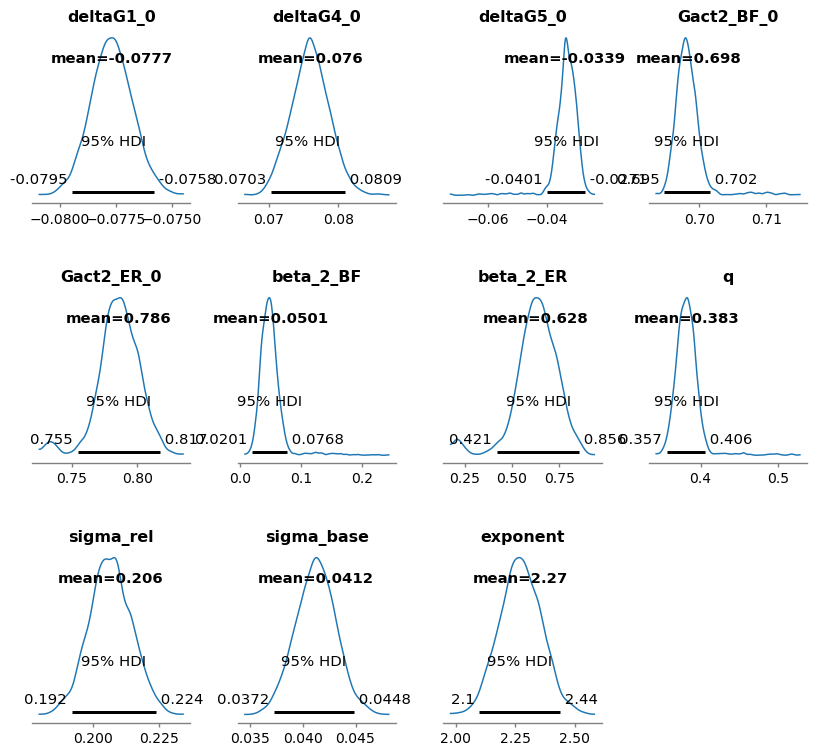

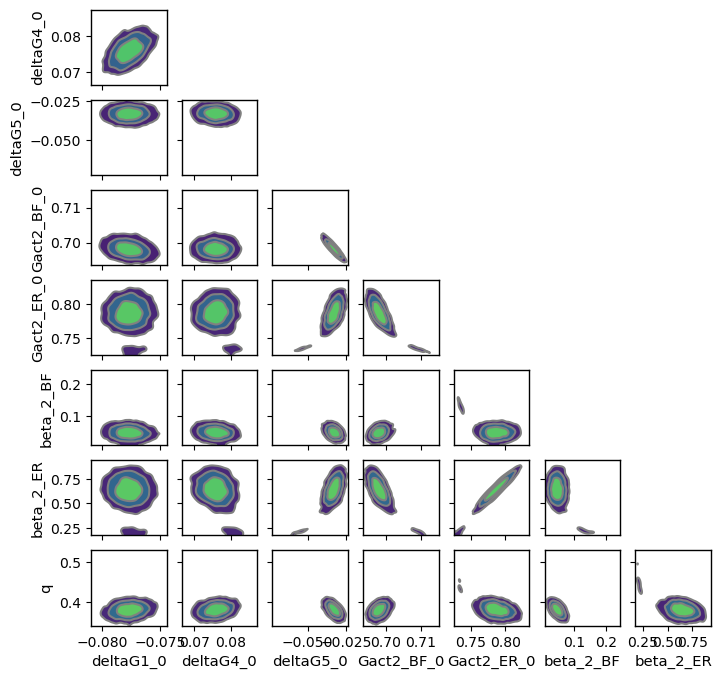

Sampling: [rate]


rate: 0.789


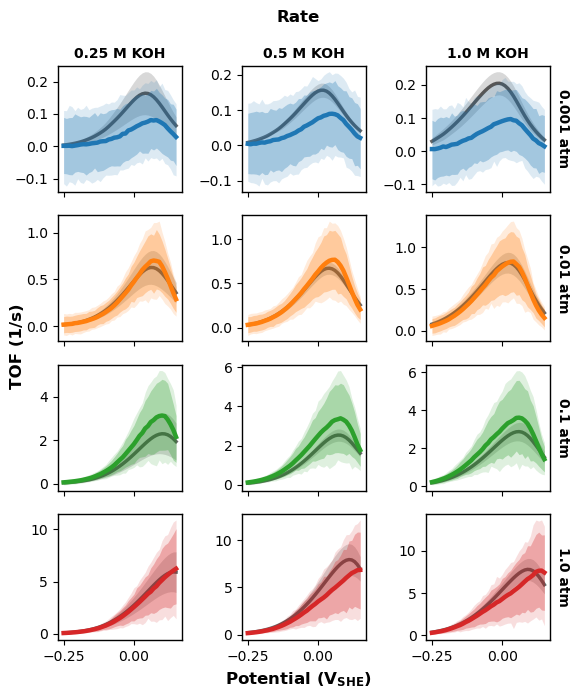

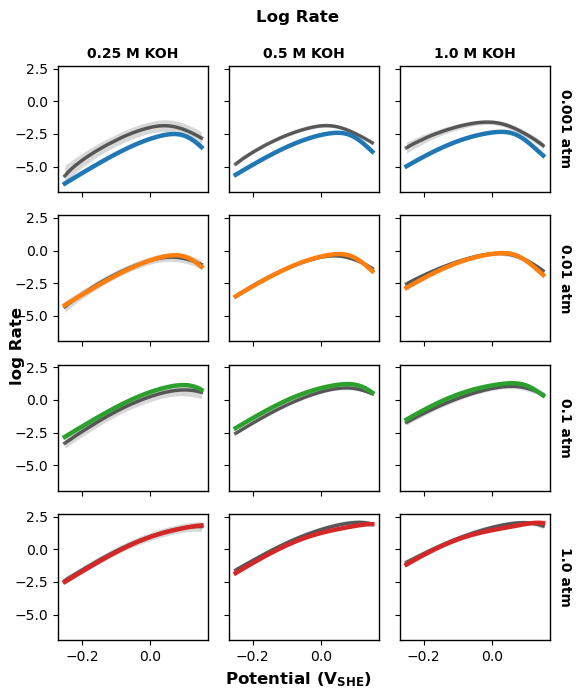

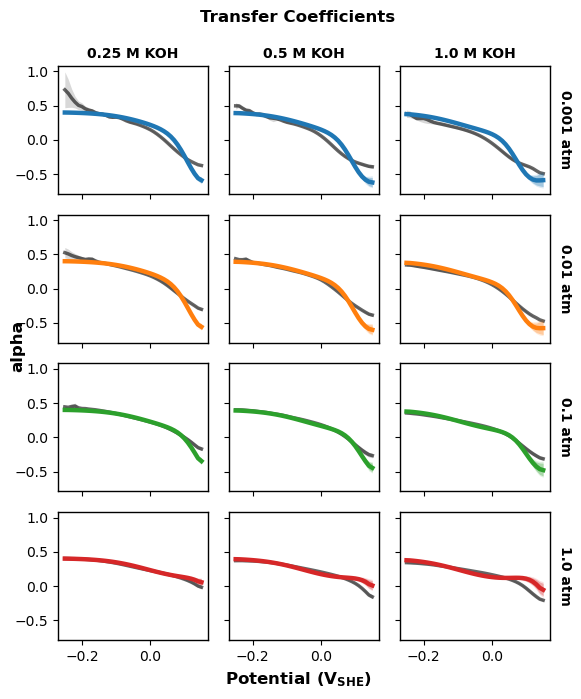

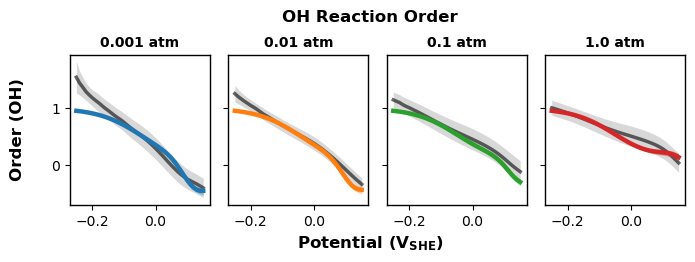

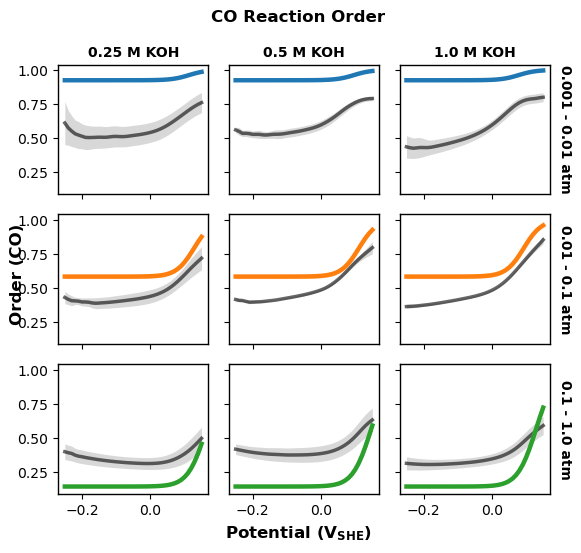

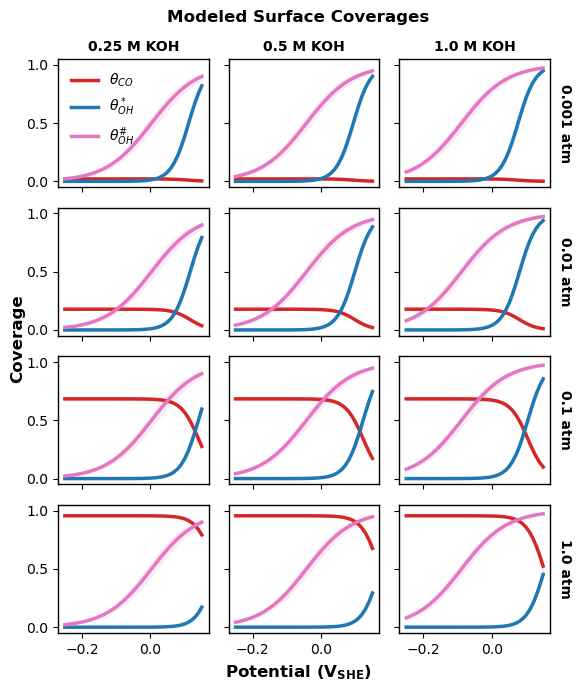

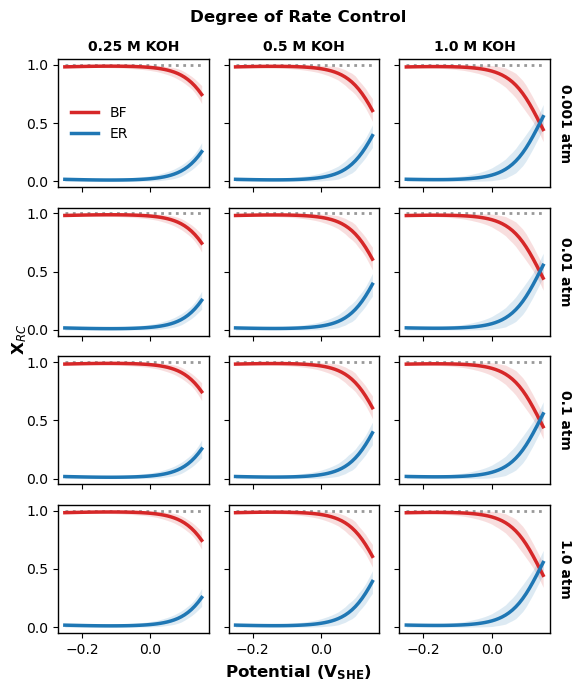

In [17]:
ppc_BF_ER_PCT_Ag = plot_posteriors(trace_BF_ER_PCT_Ag, BF_ER_PCT_Ag)
plot_model_fits(trace_BF_ER_PCT_Ag, ppc_BF_ER_PCT_Ag); plot_coverages(trace_BF_ER_PCT_Ag)
plot_drc(BF_ER_PCT_Ag, trace_BF_ER_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF LH ER PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.07,127
,3000,0,0.07,63
,3000,0,0.07,63
,3000,0,0.07,95


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   520.95    54.49
p_loo       11.62        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



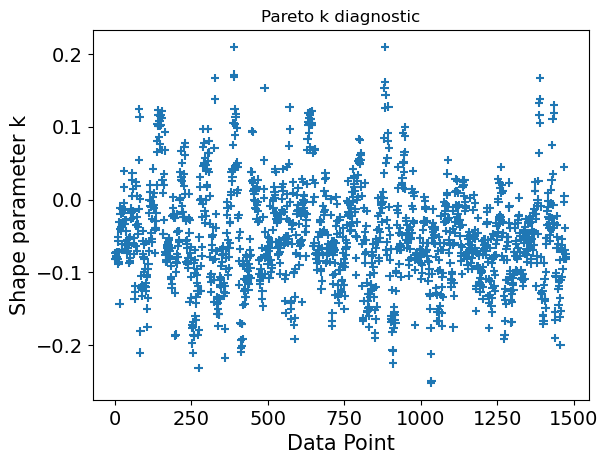

In [18]:
with pm.Model() as BF_LH_ER_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH* -> COOH* + * (RDS) (LH)
    2c. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_LH, log_rate_ER]), axis=0)
    rate = observables(log_rate) 

trace_BF_LH_ER_PCT_Ag, loo_BF_LH_ER_PCT_Ag = fit_and_evaluate(BF_LH_ER_PCT_Ag, target_accept=0.99)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.078  0.001  -0.080   -0.076      0.000    0.000    3021.0    2339.0   1.00
deltaG4_0   0.076  0.003   0.071    0.081      0.000    0.000    2688.0    2588.0   1.00
deltaG5_0  -0.033  0.003  -0.038   -0.028      0.000    0.000     990.0    1321.0   1.00
Gact2_BF_0  0.698  0.001   0.695    0.701      0.000    0.000     890.0    1173.0   1.00
Gact2_LH_0  0.873  0.120   0.693    1.089      0.002    0.002    3306.0    2116.0   1.00
Gact2_ER_0  0.787  0.014   0.762    0.814      0.000    0.000     842.0    1300.0   1.01
beta_2_BF   0.047  0.013   0.025    0.072      0.000    0.000    2032.0    2054.0   1.00
beta_2_ER   0.640  0.097   0.462    0.817      0.003    0.002     896.0    1114.0   1.01
q           0.381  0.012   0.358    0.401      0.000    0.000    1702.0    2432.0   1.00
sigma_rel   0.207  0.008   0.192    0.224      0.000    0.000    5044.0    3276.0   1.00
sigma_base  0.041  0.

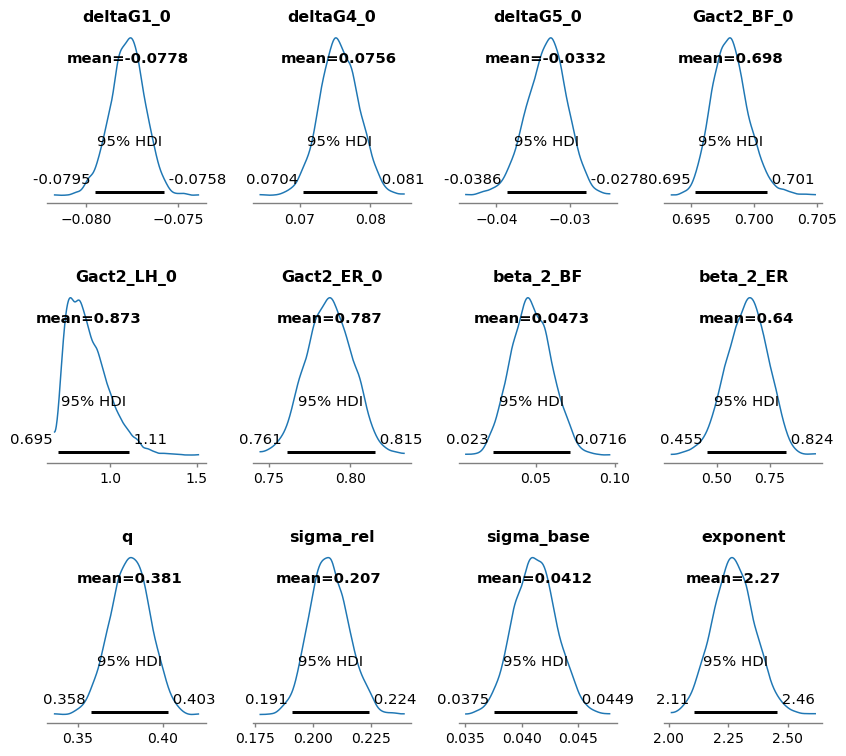

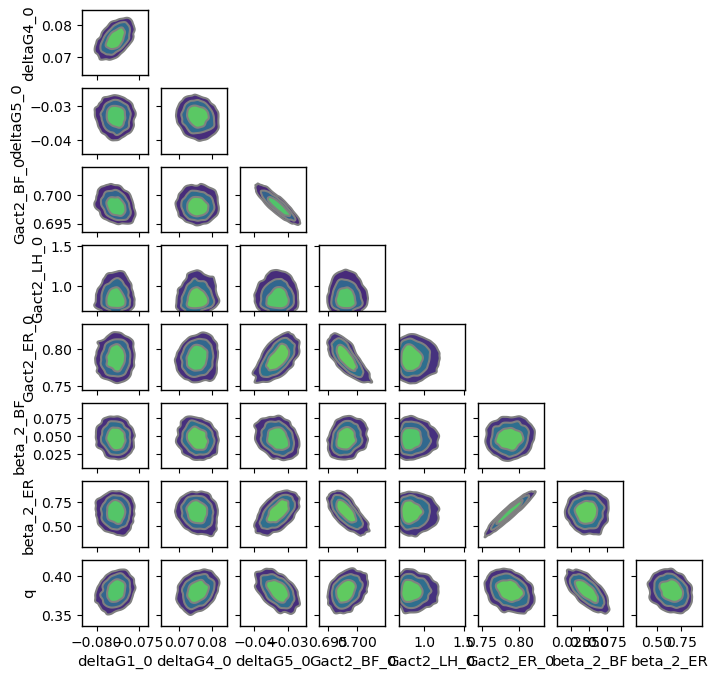

Sampling: [rate]


rate: 0.789


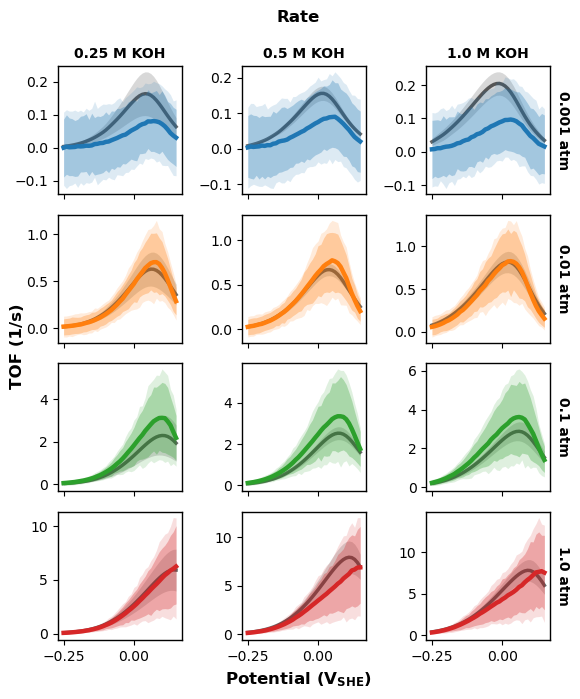

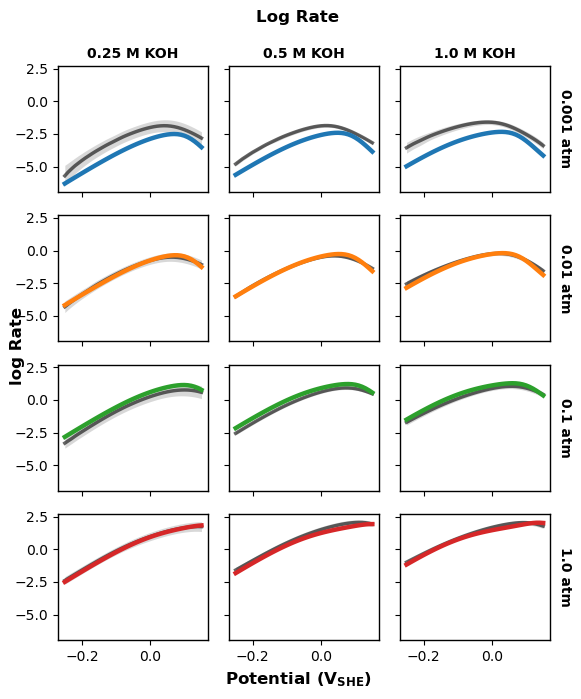

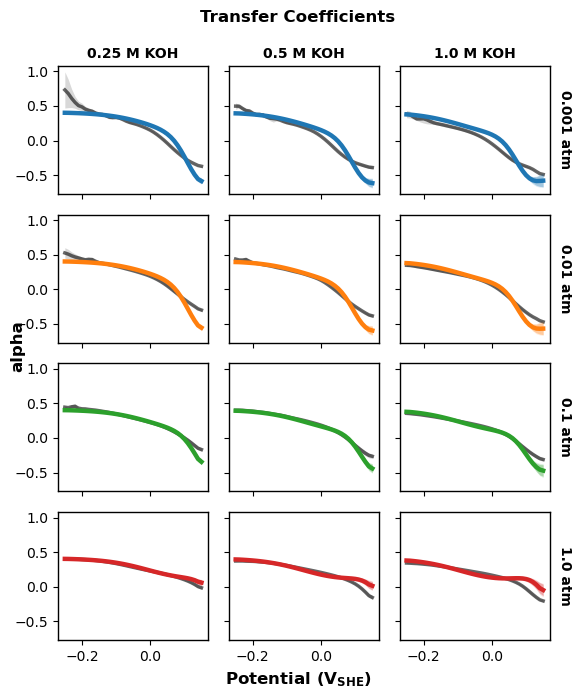

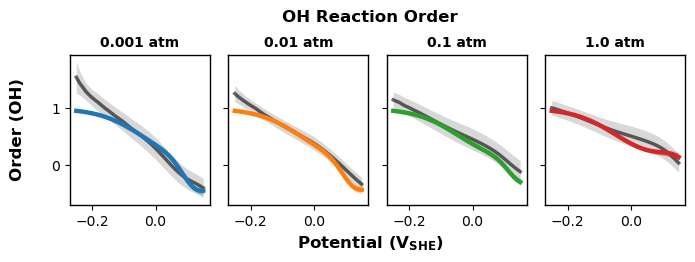

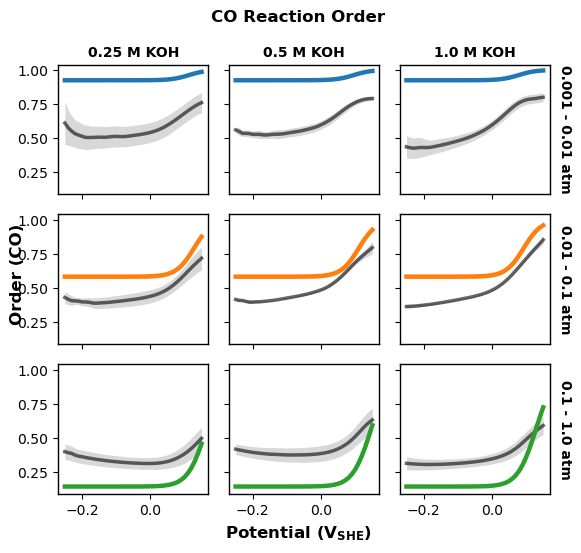

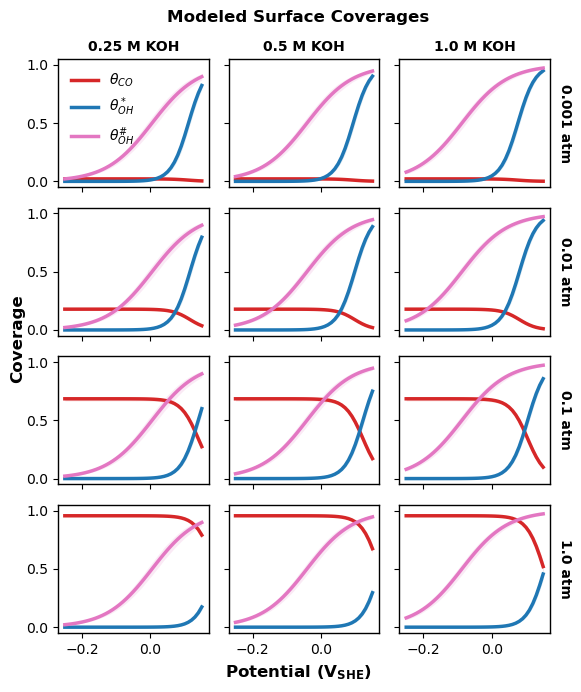

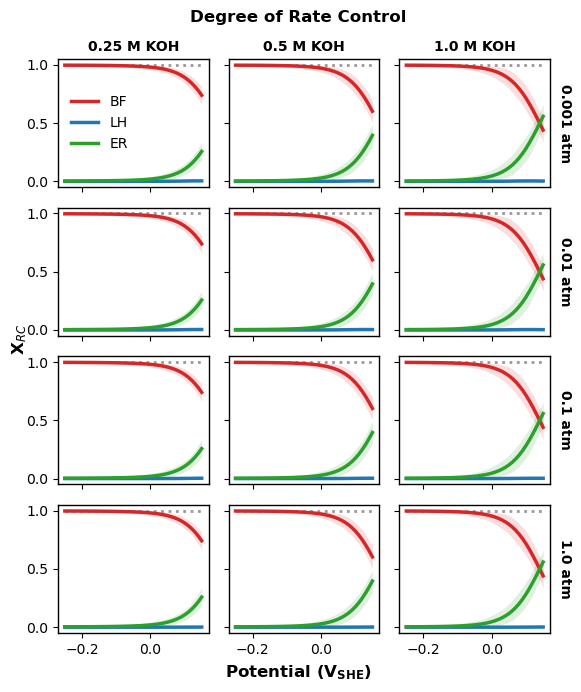

In [19]:
ppc_BF_LH_ER_PCT_Ag = plot_posteriors(trace_BF_LH_ER_PCT_Ag, BF_LH_ER_PCT_Ag)
plot_model_fits(trace_BF_LH_ER_PCT_Ag, ppc_BF_LH_ER_PCT_Ag); plot_coverages(trace_BF_LH_ER_PCT_Ag)
plot_drc(BF_LH_ER_PCT_Ag, trace_BF_LH_ER_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_LH_0', 'Gact2_ER_0'], perturb_labels=['BF', 'LH', 'ER'])

# CO BF PCT Ag 

In [20]:
with pm.Model() as CO_BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.2)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH_Ag)
    log_theta_Ag = -pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    log_A_Pd = pt.logsumexp(pt.stack([zeros, term_OH_Pd]), axis=0) 
    log_k1_PCO = log_k1 + np.log(P_CO_in)                    
    log_k_minus_1 = log_k1 - log_K1                                
    log_k_BF_app = log_k2 + log_theta_OH_Ag + np.log(Ag_comp)     
    log_denom_Pd = pt.logsumexp(pt.stack([log_k1_PCO, log_A_Pd + log_k_minus_1, log_A_Pd + log_k_BF_app]), axis=0)

    # Calculate final coverages exactly
    log_theta_CO = log_k1_PCO - log_denom_Pd
    log_theta_Pd = pt.logsumexp(pt.stack([log_k_minus_1 + zeros, log_k_BF_app]), axis=0) - log_denom_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k_BF_app + log_theta_CO
    rate = observables(log_rate) 

# trace_CO_BF_PCT_Ag, loo_CO_BF_PCT_Ag = fit_and_evaluate(CO_BF_PCT_Ag)

In [21]:
# ppc_CO_BF_LH_PCT_Ag = plot_posteriors(trace_CO_BF_PCT_Ag, CO_BF_PCT_Ag)#
# plot_model_fits(trace_CO_BF_PCT_Ag, ppc_CO_BF_LH_PCT_Ag); plot_coverages(trace_CO_BF_PCT_Ag)
# plot_drc(CO_BF_PCT_Ag, trace_CO_BF_PCT_Ag, perturb_vars=['Gact2_0', 'Gact1_0'], perturb_labels=['BF', 'CO ads'])

# OH Ag BF PCT Ag

In [22]:
with pm.Model() as OH_Ag_BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    beta_5 = pm.Beta('beta_5', alpha=5, beta=5)
    q = pm.Beta('q', alpha=10, beta=10)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    Gact5_0 = pm.Normal('Gact5_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    Gact5 = Gact5_0 - beta_5 * q * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k5 = np.log(kb_J*T/h) - Gact5/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_k5_CKOH = log_k5 + np.log(C_KOH_in)
    log_k_minus_5 = log_k5 - log_K5
    log_k2_theta_CO = log_k2 + log_theta_CO
    log_den_Ag = pt.logsumexp(pt.stack([log_k5_CKOH, log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_OH_Ag = log_k5_CKOH - log_den_Ag
    log_num_empty_Ag = pt.logsumexp(pt.stack([log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_empty_Ag = log_num_empty_Ag - log_den_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_empty_Ag))

    # Rate expression 
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate)
    
# trace_OH_Ag_BF_PCT_Ag, loo_OH_Ag_BF_PCT_Ag = fit_and_evaluate(OH_Ag_BF_PCT_Ag)

In [23]:
# ppc_OH_Ag_BF_PCT_Ag = plot_posteriors(trace_OH_Ag_BF_PCT_Ag, OH_Ag_BF_PCT_Ag)
# plot_model_fits(trace_OH_Ag_BF_PCT_Ag, ppc_OH_Ag_BF_PCT_Ag); plot_coverages(trace_OH_Ag_BF_PCT_Ag)
# plot_drc(OH_Ag_BF_PCT_Ag, trace_OH_Ag_BF_PCT_Ag, perturb_vars=['Gact2_0', 'Gact5_0'], perturb_labels=['BF', 'OH Ag ads'])

# BF LH PCT Ag Pd

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.27,63
,3000,0,0.26,15
,3000,0,0.23,47
,3000,0,0.23,63


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   511.57    54.27
p_loo       11.19        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



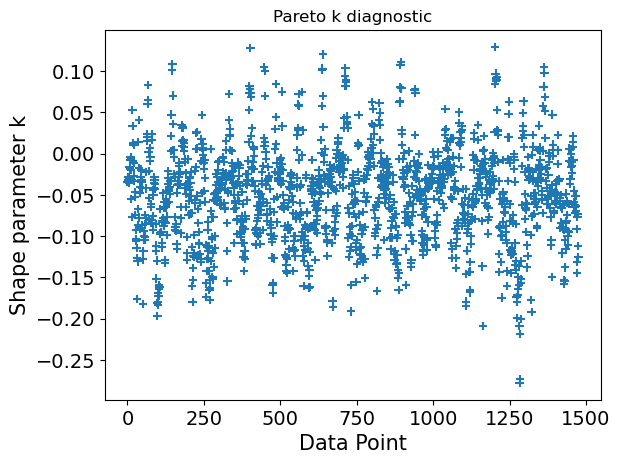

In [24]:
with pm.Model() as BF_LH_PCT_Ag_Pd:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q5-1)# -> COOH* + # + (1-q5)(e-) (RDS) (BF)
    2b. CO* + OH(q4-1)* -> COOH* + * + (1-q4)(e-) (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH(q4-1)* + (q4)(e-) (QEA)
    5. OH- + # <-> OH(q5-1)# + (q5)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    # beta_2_LH = pm.Beta('beta_2_LH', alpha=5, beta=5)
    q4 = pm.Beta('q4', alpha=10, beta=1)
    q5 = pm.Beta('q5', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    # Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q4 * E_in
    deltaG5 = deltaG5_0 - q5 * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q5) * E_in
    # Gact2_LH = Gact2_LH_0 - beta_2_LH * (1.0 - q4) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    # log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    # log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    # log_rate = pt.logaddexp(log_rate_BF, log_rate_LH)
    rate = observables(log_rate_BF) 

trace_BF_LH_PCT_Ag_Pd, loo_BF_LH_PCT_Ag_Pd = fit_and_evaluate(BF_LH_PCT_Ag_Pd)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.079  0.001  -0.081   -0.077      0.000    0.000    2327.0    2229.0    1.0
deltaG4_0   0.047  0.006   0.036    0.057      0.000    0.000    1249.0    1494.0    1.0
deltaG5_0  -0.023  0.003  -0.028   -0.018      0.000    0.000    1346.0    1630.0    1.0
Gact2_BF_0  0.692  0.001   0.690    0.695      0.000    0.000    1342.0    1438.0    1.0
beta_2_BF   0.079  0.013   0.054    0.103      0.000    0.000    1730.0    1879.0    1.0
q4          0.740  0.036   0.671    0.807      0.001    0.001    1443.0    1915.0    1.0
q5          0.332  0.013   0.309    0.356      0.000    0.000    2012.0    2142.0    1.0
sigma_rel   0.210  0.008   0.194    0.225      0.000    0.000    4740.0    3307.0    1.0
sigma_base  0.041  0.002   0.037    0.045      0.000    0.000    4618.0    2463.0    1.0
exponent    2.216  0.093   2.055    2.400      0.002    0.001    3799.0    3207.0    1.0


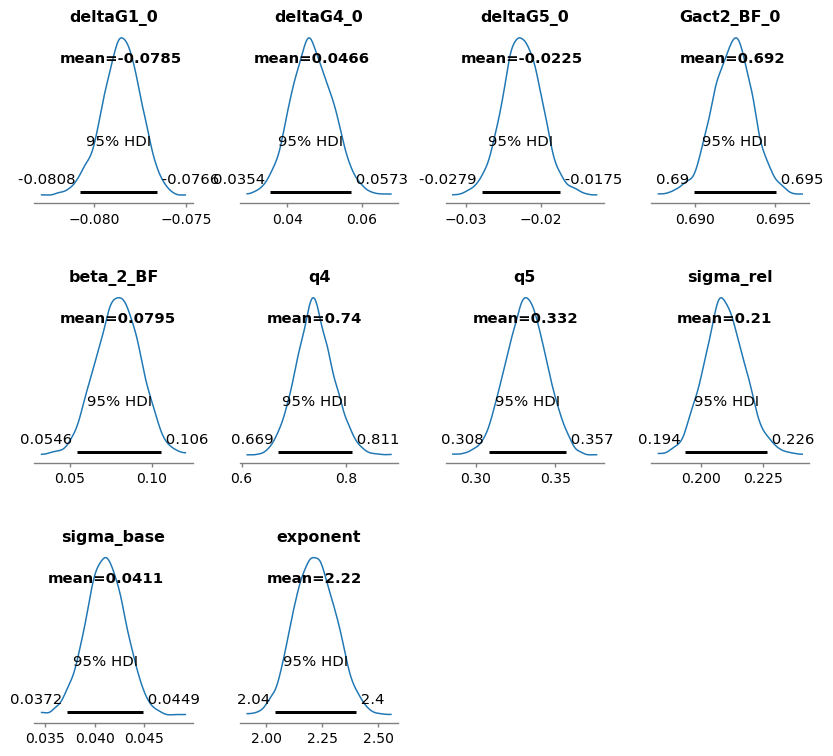

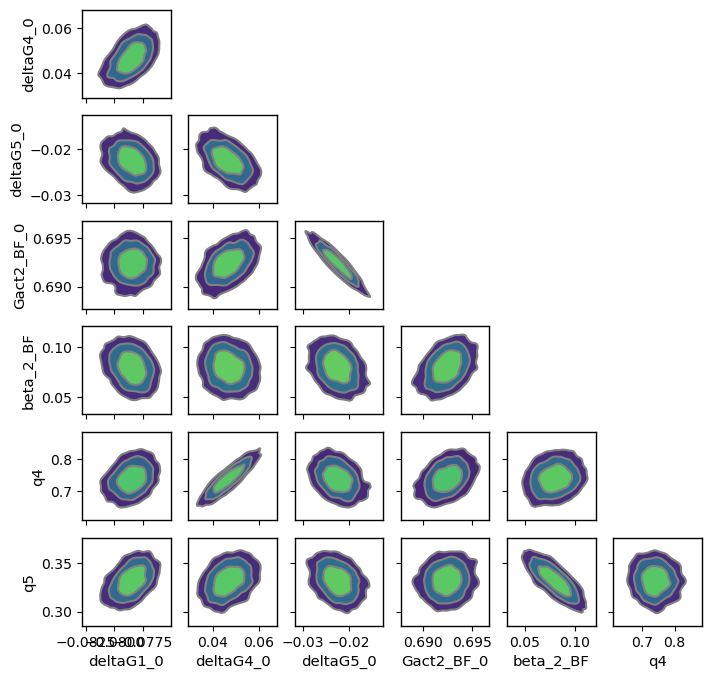

Sampling: [rate]


rate: 0.797


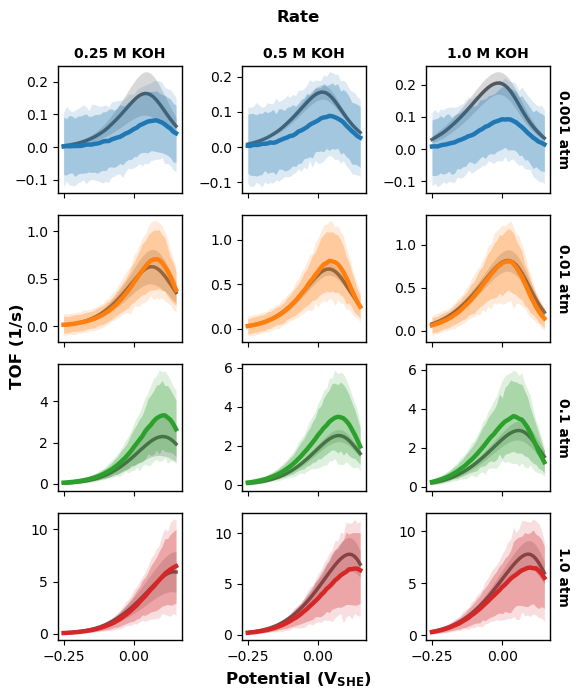

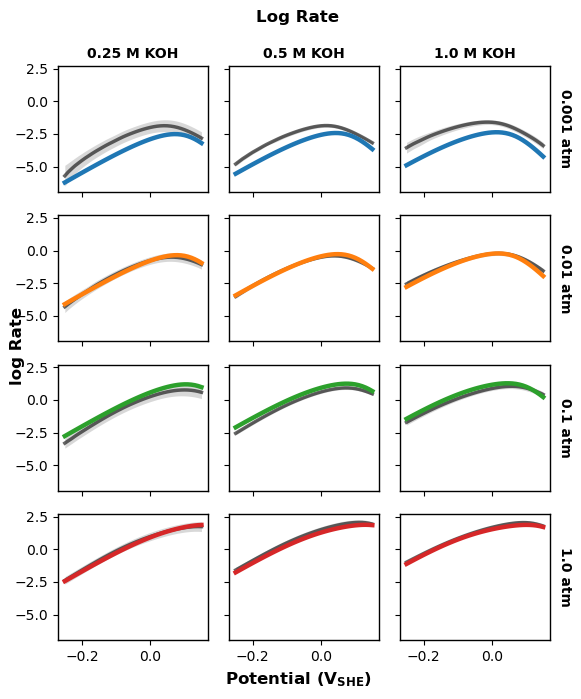

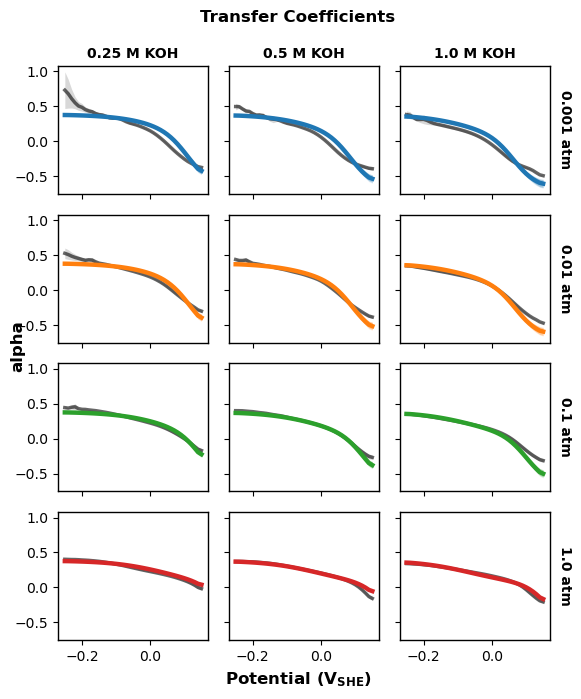

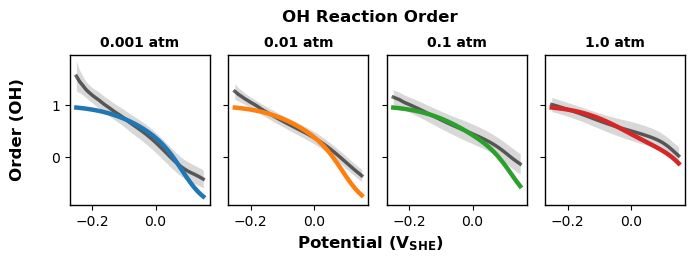

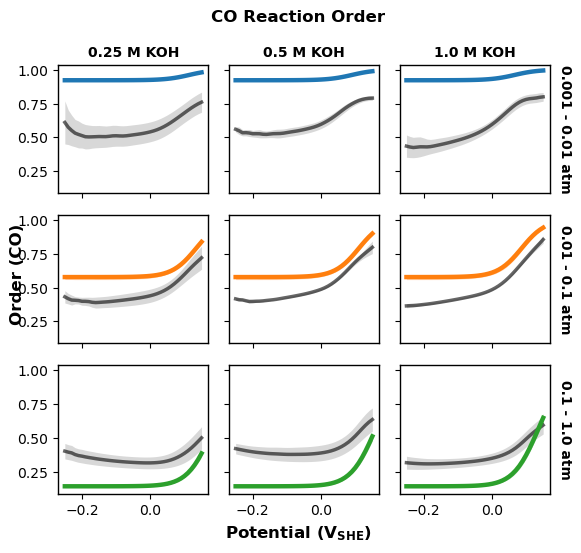

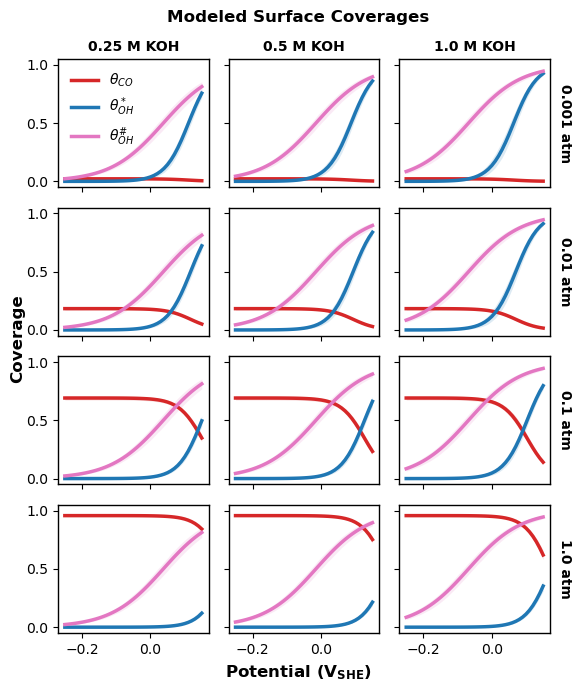

In [25]:
ppc_BF_LH_PCT_Ag_Pd = plot_posteriors(trace_BF_LH_PCT_Ag_Pd, BF_LH_PCT_Ag_Pd)
plot_model_fits(trace_BF_LH_PCT_Ag_Pd, ppc_BF_LH_PCT_Ag_Pd); plot_coverages(trace_BF_LH_PCT_Ag_Pd)

# Comparison

              rank    elpd_loo      p_loo  elpd_diff    weight         se        dse  warning scale
BF_ER_PCT_Ag     0  520.690571  12.056594    0.00000  0.924232  54.488347   0.000000    False   log
BF_ER_LH         1  409.609211  14.500419  111.08136  0.075768  57.346328  16.678224    False   log


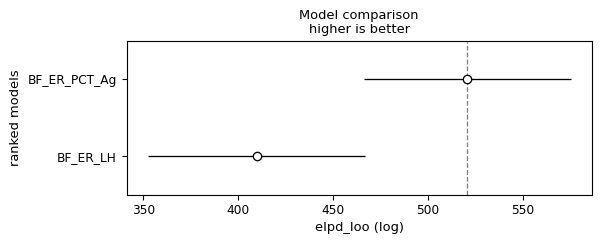

In [35]:
comparison_dict = {
    # "LH": loo_LH, # Low ELPD - bad fits
    # "BF": loo_BF, # Low ELPD - bad fits
    # "ER": loo_ER, # Moderate ELPD
    #"BF_ER": loo_BF_ER, # Should be equivalent to BF_PCT_Ag
    "BF_ER_LH": loo_BF_ER_LH, # Should be equivalent to BF_LH_PCT_Ag, but is not. 
    # "BF_PCT_Ag": loo_BF_PCT_Ag, # Good model! 
    # "BF_LH_PCT_Ag": loo_BF_LH_PCT_Ag, # LH DRC too low. 
    "BF_ER_PCT_Ag": loo_BF_ER_PCT_Ag, # ER has low DRCs. 
    # "BF_LH_ER_PCT_Ag": loo_BF_LH_ER_PCT_Ag, # Both LH and ER have low DRCs. 
    # "CO_BF_PCT_Ag": loo_CO_BF_PCT_Ag, # CO adsorption DRC is negligible. 
    # "OH_Ag_BF_PCT_Ag": loo_OH_Ag_BF_PCT_Ag, # High ELPD, but unphysical. Very low CO binding energy. Suggests OH ads on Ag has high DRCs. 
    # "BF_LH_PCT_Ag_Pd": loo_BF_LH_PCT_Ag_Pd # Minimal ELPD increase - LH has low DRCs. 
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()